In [1]:
!pip install gymnasium

In [2]:
!pip install sb3-contrib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sb3-contrib]


In [2]:
import sys
sys.path.append("/project_ghent/chronocooked")

In [3]:
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator

In [4]:
from singleagent.rl_environments.bisection_task import ChronoCookedBisectionTask

In [5]:
from scipy.stats import linregress

In [6]:
# map seed to each starting point
env = ChronoCookedBisectionTask(max_timesteps=200)
seeds = {(int(ax),int(ay)): -1 for ax, ay in zip(np.where(env.reset(seed=0)[0][:,:,0] ==0)[0],np.where(env.reset(seed=0)[0][:,:,0] ==0)[1])}
for s in range(1,30,1):
    ax, ay = np.where(env.reset(seed=s)[0][:,:,1] ==1)
    if seeds[int(ax[0]),int(ay[0])] == -1:
        seeds[int(ax[0]),int(ay[0])] = s
seeds

oven duration selected 6
oven duration selected 6
oven duration selected 6
oven duration selected 6
oven duration selected 12
oven duration selected 6
oven duration selected 12
oven duration selected 6
oven duration selected 6
oven duration selected 12
oven duration selected 12
oven duration selected 6
oven duration selected 12
oven duration selected 12
oven duration selected 6
oven duration selected 6
oven duration selected 6
oven duration selected 12
oven duration selected 6
oven duration selected 6
oven duration selected 12
oven duration selected 12
oven duration selected 12
oven duration selected 12
oven duration selected 6
oven duration selected 12
oven duration selected 6
oven duration selected 12
oven duration selected 12
oven duration selected 12
oven duration selected 12


{(1, 0): 2,
 (1, 1): 6,
 (1, 2): 1,
 (2, 0): 3,
 (2, 1): 5,
 (2, 2): 7,
 (3, 0): 17,
 (3, 2): 9}

In [ ]:
# get ts with 85% correct on anchor durations 
# bisection done with one participant performance - so do not mix ts
# train with longer gaps (optional) (4-6, 4-20)
# BP - equally likely to categorize as long and short - 
#    - switch from lower than 50% long to higher than 50% long since the time step in this case are interger. BP can be simply the point of switch 
    # - stimulus spacing is linear - some human studies have found the bp to be closer to am in this case than gm 
    # - offers insigths into internal representaions of timing 
# DL sensitivity - lower dl more sensitive 
#  - humans show greater time sensitiveity for more difficult l/s ratio 
# - steeper slope -> small weber ration-> better discriminability a participant can perceive smaller changes in stimulus duration - in our case integer changes 
#  compare lstm with different memory - for a given set of durations 
#   - webers law s/l p(t) = p(kt) for ks/kl
# how to combine data for multiple participants ? - since different models for each anchor pair. wf and dl comparison is like comparing data from different participants
# make a different psychometric curve for each ts and calculate the bp, dl and wf. report average bp, dl, wf 
# for wf and dl - train anchors with same gaps (linear spacing) for superimposotion. 4-6, 8-10, 18-20, 4-12, 8-16, 18-24 
# LSTM memory capacity 
# compare convergence point of different lstm memory and animals or humans 

In [7]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

In [8]:
import matplotlib as mpl

mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

In [9]:
# fit sigmoid curve
def logistic(x, x0, k):
    return 1 / (1 + np.exp(-(x - x0) / k))

def inv_logistic(p, x0, k):
    return x0 + k * np.log(p / (1 - p))

In [10]:
# plot psychometric curve - consider cases with delivery counter -1 (failed soup delivery)

def get_plong(responses):
    vals = [x for x in responses if x != -1]  # remove failed soup delivery cases 
    
    if len(vals) <0.5*len(responses): # >50% of seeds fail - skip that td. case 1: missing few tds, handled by logistic fit, case 2: all td fails, hanfled by ignoring nans while plotting and calculating 
        pct_long = np.nan
    else:
        pct_long = (vals.count(2) / len(vals)) #percentage calculated ignoring failed soup deliveries. becuase failed soup delivery should not affect timing performance calculation
    
    return pct_long


# across runs/pids
def get_plong_across_runs(anchor_data, label):
    participant_plong = {}
    short = int(label.split("-")[0])
    long = int(label.split("-")[-1])
    for pid, data in anchor_data.items():
        participant_plong[pid] = {}
        for duration, responses in sorted(data.items()):
            # vals = [x for x in responses if x != -1]  # remove failed soup delivery cases 

            # if len(vals) <0.5*len(responses): # >50% of seeds fail - skip that td. case 1: missing few tds, handled by logistic fit, case 2: all td fails, hanfled by ignoring nans while plotting and calculating 
            #     pct_long = np.nan
            # else:
            #     pct_long = (vals.count(2) / len(vals)) #percentage calculated ignoring failed soup deliveries. becuase failed soup delivery should not affect timing performance calculation
           
            participant_plong[pid][duration] = get_plong(responses)
    return participant_plong


def plot_psychometric_curve(durations, percent_long, label, zorder=3, color="grey", linewidth=2, scatterplot_zorder=2, 
                            scatterplot_color="grey",ax=None, alpha=1 ):
    if ax is None:
        ax = plt.gca()
     # add mask to remove tds with nan values (>50% failed seeds) before logistic curve fitting
    mask = (np.isfinite(durations) & np.isfinite(percent_long))
    
    durations_fit = np.array(durations)[mask]
    percent_long_fit = np.array(percent_long)[mask]

    initial_params=[am, 1.0]  #helps to avoid very low x0 (failed timing). With inital param such x0 becomes invalid
    bp = t25 =t75=jnd = -100  # curves with failed timing task - bad sigmoid fit with always above or below 0.5. Nan for failed soup delivery 
    # sigmoid curve fitting
    try:
        params, _ = curve_fit(logistic, durations_fit, percent_long_fit, p0=initial_params)
        x0, k = params
        x_fit = np.linspace(min(durations_fit), max(durations_fit), 200)
        y_fit = logistic(x_fit, x0, k)
        if (x0 <= np.min(durations_fit)) or (x0>=np.max(durations_fit)): # invalid x0: failed timing as line always above or below 0.5 for all td
            # ax.plot(x_fit, y_fit, label="Logistic fit", color="grey", linestyle="--", alpha=0.5, linewidth=2, zorder =3)
            print("failed timing task since x0 out of range")
        else:
            # only show good sigmoid fits in grey solid lines 
            ax.plot(x_fit, y_fit, label="Logistic fit", color=color, linestyle="-", alpha=alpha, linewidth=linewidth, zorder =zorder) # size
            bp = round(inv_logistic(0.5, x0, k),3)
            t25 = round(inv_logistic(0.25, x0, k),3)
            t75 = round(inv_logistic(0.75, x0, k),3)
            jnd = round(0.5*(inv_logistic(0.75, x0, k)-inv_logistic(0.25, x0, k)),3)
    except: # sigmoid did not fit. either a step function (valid) or not a valid sigmoid (failed timing task) or failed soup delivey 
        x0 = 0
        k = 0        
        if len(percent_long_fit)==0: # failed soup delivery 
            print("failed soup delivery")
            bp = t25 =t75=jnd = None
        elif np.nanmean(percent_long[0:short]) <=0.2 and np.nanmean(percent_long[long:]) >=0.8: # strict , FN - good psychometric (mostly step) that does not fit logistic 
                bp = round(((np.min([k for k, v in enumerate(percent_long) if np.isfinite(v) and v>=0.5]) 
                             + np.max([k for k, v in enumerate(percent_long) if np.isfinite(v) and v<=0.5]))/2),3) 
                t25 = (np.min([k for k, v in enumerate(percent_long) if np.isfinite(v) and v>=0.25])
                       + np.max([k for k, v in enumerate(percent_long) if np.isfinite(v) and v<=0.25]))/2
                t75 = (np.min([k for k, v in enumerate(percent_long) if np.isfinite(v) and v>=0.75]) 
                       + np.max([k for k, v in enumerate(percent_long) if np.isfinite(v) and v<=0.75]))/2
                jnd = round(0.5*(t75-t25),3)
                ax.plot(durations_fit, percent_long_fit, label="Logistic fit", color=color, linestyle="-", alpha=alpha, linewidth=linewidth, zorder =zorder)
        else:
            print("failed timing task: could not fit a sigmoid or calculate bp manually") #failed timing task - not a good s shaped curve 
   
        
    # Plot all responses 
    # ax.scatter(durations, percent_long, marker='o', label="Data", color="grey", alpha=0.5,s=15) #size
    ax.scatter(durations, percent_long, marker='o', label="Data", color=scatterplot_color, alpha=alpha, zorder=scatterplot_zorder) # handles nans by not plotting
    # ax.plot(x_fit, y_fit, label="Logistic fit", color="red")
    # ax.axhline(0.5, linestyle='--', color="blue",linewidth=1, zorder=1) # size
    ax.set_title( label,fontweight='bold')
    ax.set_xticks(range(0,long+5,4))
    return x0, k, bp, t25, t75, jnd
    

# per run 
def psychometric_curve_per_run(data, label, ax=None,):
    if ax is None:
        ax = plt.gca()
        
    durations = []
    percent_long = []
    short = int(label.split("-")[0])
    long = int(label.split("-")[-1])
    for duration, responses in sorted(data.items()):
        # vals = [x for x in responses if x != -1]  # remove failed soup delivery cases 

        # if len(vals) <0.5*len(responses): # >50% of seeds fail - skip that td. case 1: missing few tds, handled by logistic fit, case 2: all td fails, hanfled by ignoring nans while plotting and calculating 
        #     pct_long = np.nan
        # else:
        #     pct_long = (vals.count(2) / len(vals)) #percentage calculated ignoring failed soup deliveries. becuase failed soup delivery should not affect timing performance calculation
        # # n_total = len(responses)
        # # n_long = sum(1 for r in responses if r == 2)
        # # pct_long = (n_long / n_total)
        pct_long = get_plong(responses)
    
        durations.append(duration)
        percent_long.append(pct_long)
        
    x0, k, bp, t25, t75, jnd = plot_psychometric_curve(durations, percent_long,ax=ax, label=label, alpha=0.5 )
    # add mask to remove tds with nan values (>50% failed seeds) before logistic curve fitting
    # mask = (np.isfinite(durations) & np.isfinite(percent_long))
    
    # durations_fit = np.array(durations)[mask]
    # percent_long_fit = np.array(percent_long)[mask]

    # initial_params=[am, 1.0]  #helps to avoid very low x0 (failed timing). With inital param such x0 becomes invalid
    # bp = t25 =t75=jnd = -100  # curves with failed timing task - bad sigmoid fit with always above or below 0.5. Nan for failed soup delivery 
    # # sigmoid curve fitting
    # try:
    #     params, _ = curve_fit(logistic, durations_fit, percent_long_fit, p0=initial_params)
    #     x0, k = params
    #     x_fit = np.linspace(min(durations_fit), max(durations_fit), 200)
    #     y_fit = logistic(x_fit, x0, k)
    #     if (x0 <= np.min(durations_fit)) or (x0>=np.max(durations_fit)): # invalid x0: failed timing as line always above or below 0.5 for all td
    #         # ax.plot(x_fit, y_fit, label="Logistic fit", color="grey", linestyle="--", alpha=0.5, linewidth=2, zorder =3)
    #         print("failed timing task since x0 out of range")
    #     else:
    #         # only show good sigmoid fits in grey solid lines 
    #         ax.plot(x_fit, y_fit, label="Logistic fit", color="grey", linestyle="-", alpha=0.5, linewidth=2, zorder =3) # size
    #         bp = round(inv_logistic(0.5, x0, k),3)
    #         t25 = round(inv_logistic(0.25, x0, k),3)
    #         t75 = round(inv_logistic(0.75, x0, k),3)
    #         jnd = round(0.5*(inv_logistic(0.75, x0, k)-inv_logistic(0.25, x0, k)),3)
    # except: # sigmoid did not fit. either a step function (valid) or not a valid sigmoid (failed timing task) or failed soup delivey 
    #     x0 = 0
    #     k = 0        
    #     if len(percent_long_fit)==0: # failed soup delivery 
    #         print("failed soup delivery")
    #         bp = t25 =t75=jnd = None
    #     elif np.nanmean(percent_long[0:short]) <=0.2 and np.nanmean(percent_long[long:]) >=0.8: # strict , FN - good psychometric (mostly step) that does not fit logistic 
    #             bp = round(((np.min([k for k, v in enumerate(percent_long) if np.isfinite(v) and v>=0.5]) 
    #                          + np.max([k for k, v in enumerate(percent_long) if np.isfinite(v) and v<=0.5]))/2),3) 
    #             t25 = (np.min([k for k, v in enumerate(percent_long) if np.isfinite(v) and v>=0.25])
    #                    + np.max([k for k, v in enumerate(percent_long) if np.isfinite(v) and v<=0.25]))/2
    #             t75 = (np.min([k for k, v in enumerate(percent_long) if np.isfinite(v) and v>=0.75]) 
    #                    + np.max([k for k, v in enumerate(percent_long) if np.isfinite(v) and v<=0.75]))/2
    #             jnd = round(0.5*(t75-t25),3)
    #             ax.plot(durations_fit, percent_long_fit, label="Logistic fit", color="grey", linestyle="-", alpha=0.5, linewidth=2, zorder =3)
    #     else:
    #         print("failed timing task: could not fit a sigmoid or calculate bp manually") #failed timing task - not a good s shaped curve 
   
        
    # # Plot all responses 
    # # ax.scatter(durations, percent_long, marker='o', label="Data", color="grey", alpha=0.5,s=15) #size
    # ax.scatter(durations, percent_long, marker='o', label="Data", color="grey", alpha=0.5, zorder=2) # handles nans by not plotting
    # # ax.plot(x_fit, y_fit, label="Logistic fit", color="red")
    # # ax.axhline(0.5, linestyle='--', color="blue",linewidth=1, zorder=1) # size
    # ax.set_title( label,fontweight='bold')
    # ax.set_xticks(range(0,long+5,4))
    return x0, k, bp, t25, t75, jnd

# for a given anchor and model - take mean across participant_plong
def groupmean_psychometric_curve(participant_plong, label,ax=None):
    if ax is None:
        ax = plt.gca()
        
    groupmean_plong = {}
    percent_long = []
    short = int(label.split("-")[0])
    long = int(label.split("-")[-1])


    n_valid = {}
    
    for data in participant_plong.values():
        if data == {}:
            continue
    
        for duration, p_long in sorted(data.items()):
    
            if np.isnan(p_long):  #failed soup delivery for this td becuase in the corresponding run >50% failed seeds for this td 
                continue # run plong is excluded from mean calculation 
    
            groupmean_plong[duration] = (
                groupmean_plong.get(duration, 0) + p_long
            )
    
            n_valid[duration] = (
                n_valid.get(duration, 0) + 1
            )
    
    if groupmean_plong == {}: # failed soup delivery in all runs 
        return np.nan, np.nan
    
    groupmean_plong = {
        duration: total / n_valid[duration]
        for duration, total in groupmean_plong.items()
    }


    # n_participants = len([v for v in participant_plong.values() if v!={}]) 
    # for data in participant_plong.values():
    #     if data == {}:
    #         continue
    #     for duration, p_long in sorted(data.items()):
    #         groupmean_plong[duration] = groupmean_plong.get(duration,0) + p_long

    # if groupmean_plong == {}:
    #     return 0, 0
    # groupmean_plong = {k: v / n_participants for k, v in groupmean_plong.items()}
    durations = list(groupmean_plong.keys())
    mean_plong = list(groupmean_plong.values())
    x0, k, bp, t25, t75, jnd =  plot_psychometric_curve(durations, mean_plong, zorder=5, color="red", linewidth=2.5, scatterplot_zorder=4,
                                                        scatterplot_color="black", ax=ax, label=label )
    
    
    # # sigmoid curve fitting
    # try:
    #     params, _ = curve_fit(logistic, durations, mean_plong)
    #     x0, k = params
    #     x_fit = np.linspace(min(durations), max(durations), 200)
    #     y_fit = logistic(x_fit, x0, k)
    #     ax.plot(x_fit, y_fit, label="Logistic fit", color="red", linewidth=2.5, zorder=4) # size
    # except:
    #     x0 =0
    #     k = 0
    #     print("could not fit a sigmoid")
    
    # # Plot
    # # ax.scatter(durations, mean_plong, marker='o', label="Data", color="black",s=15) # size
    # ax.scatter(durations, mean_plong, marker='o', label="Data", color="black", zorder=2)
    # # ax.plot(x_fit, y_fit, label="Logistic fit", color="red")
    # # ax.axhline(0.5, linestyle='--',color="blue",linewidth=1,zorder=1) # size
    # ax.set_title(label, fontweight='bold')
    # ax.set_xticks(range(0,long+5,4))
    return x0, k, bp, t25, t75, jnd

def groupmean_superimposition_plot(participant_plong, label,x_norm, ax=None, color=None):
    if ax is None:
        ax = plt.gca()
    

    groupmean_plong = {}
    percent_long = []

    short = int(label.split("-")[0])
    long = int(label.split("-")[-1])
    n_valid = {}
    
    for data in participant_plong.values():
        if data == {}:
            continue
    
        for duration, p_long in sorted(data.items()):
    
            if np.isnan(p_long):  #failed soup delivery for this td becuase in the corresponding run >50% failed seeds for this td 
                continue # run plong is excluded from mean calculation 
    
            groupmean_plong[duration] = (
                groupmean_plong.get(duration, 0) + p_long
            )
    
            n_valid[duration] = (
                n_valid.get(duration, 0) + 1
            )
    
    if groupmean_plong == {}: # failed soup delivery in all runs 
        return np.nan, np.nan
    
    groupmean_plong = {
        duration: total / n_valid[duration]
        for duration, total in groupmean_plong.items()
    }
    durations = list(groupmean_plong.keys())
    mean_plong = list(groupmean_plong.values())
    x0, k, bp, t25, t75, jnd =  plot_psychometric_curve(durations, mean_plong, zorder=5, color="red", linewidth=2.5, scatterplot_zorder=4,
                                                    scatterplot_color="black", ax=None, label=label )


    # # sigmoid curve fitting
    # try:
    #     params, _ = curve_fit(logistic, durations, mean_plong)
    #     x0, k = params
    #     x_fit = np.linspace(min(durations), max(durations), 200)
    #     y_fit = logistic(x_fit, x0, k)
    #     # ax.plot(x_fit, y_fit, label="Logistic fit", color="red")
    #     bp = round(inv_logistic(0.5, x0, k),3)
    # except:
    #     x0, k = (0,0)
    #     bp = round(((np.min([k for k, v in groupmean_plong.items() if v>=0.5]) + np.max([k for k, v in groupmean_plong.items() if v<=0.5]))/2),3)
    #     print("could not fit a sigmoid")
        
    if x_norm == "bp":
        x_norm = [x / bp  for x in durations]
        title = "Scalar law"
        xlabel = "t / pse"
    elif x_norm == "short":
        x_norm = [x / short  for x in durations]
        title = "Weber law"
        xlabel = "t / S"
    else:
        x_norm = [x  for x in durations]
        title == "raw data"
        xlabel = "Probe duration"
            
    if color:
        ax.plot(x_norm, mean_plong, marker='o', label=label,color="cyan")
    else:
        ax.plot(x_norm, mean_plong, marker='o', label=label,color="cyan")

  

    # plt.ylim(-0.1, 1.1)
    # plt.xticks(range(24))
    ax.axhline(0.5, linestyle='--', color="black")
    ax.set_xlabel(xlabel)
    ax.legend(title="Anchor")
    ax.set_title(title)
    # plt.grid(True)



In [11]:
def get_eplen_across_training(tb_event_file, max_training_ts_env0):
    ea = event_accumulator.EventAccumulator(tb_event_file)
    ea.Reload()
    eplen = ea.Scalars("rollout/ep_len_mean") 
    eplen_dict = {a_kl.step:a_kl.value for a_kl in eplen if (a_kl.step % 20000 == 0) & (a_kl.step>max_training_ts_env0)}
    return eplen_dict

In [12]:
def get_task_performance(lstm_size=None, ctrnn=False):
    
    delivery_counter_used_history = {}
    timing_actions_history = {}
    
    short_durations=(2, 3, 4, 6, 7)
    long_durations=(6, 8 , 9, 12 , 14, 18, 21, 24, 32)
    ent_coeff = 0
    timestep = 200
    g = 0.99
    
    
    for short_duration in short_durations:
        for long_duration in long_durations:
            
            delivery_counter_used_history[f"{short_duration}-{long_duration}"] = {}
            timing_actions_history[f"{short_duration}-{long_duration}"] = {}
            
            if lstm_size in [125,256]:
                p_ids = zip([1,2,3,4],[950000,950000,950000,950000])
            elif lstm_size is None:
                p_ids = zip([1,2,3,4],[950000,950000,950000,950000])
            elif ctrnn and lstm_size==8:
                p_ids = zip([1,2],[950000,950000])
            elif lstm_size==8:
                p_ids = zip([2,3,4],[950000,950000,950000,950000])
            else:
                print("no valid p_id given for size, ctrnn", lstm_size, ctrnn)
            for log, ts in p_ids:
                delivery_counter_used_history[f"{short_duration}-{long_duration}"][f"{log}-{ts}"] = {}
                timing_actions_history[f"{short_duration}-{long_duration}"][f"{log}-{ts}"] = {}

            
                models_folder = "/project_ghent/chronocooked/singleagent/train/bisection_modelsv1"
                if ctrnn:
                    model_file = f"bisectionv1_TD1{short_duration}_TD2{long_duration}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_ctrnn{lstm_size}_mlp64_gamma{g}_logs{log}/"
                elif lstm_size is None:
                    model_file = f"bisectionv1_TD1{short_duration}_TD2{long_duration}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_mlp64_gamma{g}_logs{log}/"
                else:
                    model_file = f"bisectionv1_TD1{short_duration}_TD2{long_duration}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_sharedlstm{lstm_size}_mlp64_gamma{g}_logs{log}/"
                # model_file_cnn = f"bisectionv1_TD1{short_duration}_TD2{long_duration}_cnnout64_ts{timestep}_entcoef{ent_coeff}_nepoch20_mlp64_gamma{g}_logs2/"
                
                env_test = ChronoCookedBisectionTask( max_timesteps=timestep, short_duration=short_duration, long_duration=long_duration)
                # model = RecurrentPPO.load(f"models/singletask_onetrial_T{target_duration}_cnnoutput64_timestep200_entcoef00_nepoch20_batch500_sharedlstm125_logs/rl_model_30000_steps.zip", env=env_test)
                try:
                    if lstm_size is None:
                        model = PPO.load(f"{models_folder}/{model_file}/rl_model_{ts}_steps.zip", env=env_test)
                    else:
                        model = RecurrentPPO.load(f"{models_folder}/{model_file}/rl_model_{ts}_steps.zip", env=env_test)
                except:
                    print("could not load",f"{models_folder}/{model_file}/rl_model_{ts}_steps.zip")
                    continue
                
                tb_event_file = f"{models_folder}/{model_file}/first_run_1"
                eplen_dict = get_eplen_across_training(tb_event_file, 0)
                # print(eplen_dict)
                if eplen_dict[list(eplen_dict.keys())[-1]] > 100:
                    print("unsuccessful timing task", model_file, eplen_dict[list(eplen_dict.keys())[-1]])
                    continue
                        
                for td in range(1,long_duration+5):
                    delivery_counter_used_td = []  
                    timing_actions = []

                    for seed in seeds.values():   
                        # model = PPO.load(f"{models_folder}/{model_file_cnn}/rl_model_950000_steps.zip")
                        # print(f)
                        obs, _ = env_test.reset(seed=seed, oven_duration=td)
                        visual_obs = np.sum(obs,axis=2)
                        obs_concat = [visual_obs]
                        act_concat = []
                        oven_timers_concat = []
                        reward_concat = []
                        # print("oven timers", env_test.oven1_timer, env_test.oven2_timer)
                        rewards=0
                        states = None
                        
                        for i in range(timestep + 2):
                            # obs = obs + 300
                            action, states = model.predict(obs, state=states, deterministic=True) 
                            act_concat.append(action)
                            oven_timers_concat.append(env_test.oven1_timer)
                            # print(visual_obs)
                            # print("action",action)
                            obs, reward, done, _ ,_= env_test.step(action)
                            visual_obs = np.sum(obs,axis=2)
                            obs_concat.append(visual_obs)
                        
                            # print("reward",reward)
                            # print("oven timer", env_test.oven_timer)
                            
                            rewards += reward
                            reward_concat.append(reward)
                            if done:
                                reward_concat.append(reward)
                                act_concat.append(0)
                                oven_timers_concat.append(env_test.oven1_timer)
                                delivery_counter_used_td.append(env_test.delivery_counter_used)
                                timing_actions.append([a for a, t in zip(act_concat, oven_timers_concat) if t != -1])
                                # obs,_ = env_test.reset()
                        
                                # print("short_duration", short_duration, "long_duration", long_duration, "rewards",rewards, "delivery counter", env_test.delivery_counter_used, i+1)
                                break
                    # if td in [short_duration, long_duration]:
                    #     if delivery_counter_used_td.count(-1) >= len(delivery_counter_used_td) / 2:
                    #         print("more than 50% seeds with unsuccessful timing task", model_file) 
                    #         continue
                        
                    delivery_counter_used_history[f"{short_duration}-{long_duration}"][f"{log}-{ts}"][td] = delivery_counter_used_td
                    timing_actions_history[f"{short_duration}-{long_duration}"][f"{log}-{ts}"][td] = timing_actions
    return delivery_counter_used_history, timing_actions_history


In [13]:
delivery_counter_used_history_8, timing_actions_history_8 = get_task_performance(lstm_size=8,ctrnn=True)
delivery_counter_used_history_125, timing_actions_history_125 = get_task_performance(lstm_size=125,ctrnn=True)
delivery_counter_used_history_256, timing_actions_history_256 = get_task_performance(lstm_size=256,ctrnn=True)

could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD26_cnnout64_ts200_entcoef0_nepoch20_ctrnn8_mlp64_gamma0.99_logs1//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD26_cnnout64_ts200_entcoef0_nepoch20_ctrnn8_mlp64_gamma0.99_logs2//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD28_cnnout64_ts200_entcoef0_nepoch20_ctrnn8_mlp64_gamma0.99_logs1//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD28_cnnout64_ts200_entcoef0_nepoch20_ctrnn8_mlp64_gamma0.99_logs2//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD29_cnnout64_ts200_entcoef0_nepoch20_ctrnn8_mlp64_gamma0.99_logs1//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/si

In [14]:
delivery_counter_used_history_lstm8, timing_actions_history_lstm8 = get_task_performance(lstm_size=8,ctrnn=False)
delivery_counter_used_history_lstm125, timing_actions_history_lstm125 = get_task_performance(lstm_size=125,ctrnn=False)
delivery_counter_used_history_lstm256, timing_actions_history_lstm256 = get_task_performance(lstm_size=256,ctrnn=False)

could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD26_cnnout64_ts200_entcoef0_nepoch20_sharedlstm8_mlp64_gamma0.99_logs2//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD26_cnnout64_ts200_entcoef0_nepoch20_sharedlstm8_mlp64_gamma0.99_logs3//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD26_cnnout64_ts200_entcoef0_nepoch20_sharedlstm8_mlp64_gamma0.99_logs4//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD28_cnnout64_ts200_entcoef0_nepoch20_sharedlstm8_mlp64_gamma0.99_logs2//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD28_cnnout64_ts200_entcoef0_nepoch20_sharedlstm8_mlp64_gamma0.99_logs3//rl_model_950000_steps.zip
could not load /proj

In [15]:
delivery_counter_used_history_cnn, timing_actions_history_cnn = get_task_performance(lstm_size=None)

could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD26_cnnout64_ts200_entcoef0_nepoch20_mlp64_gamma0.99_logs1//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD26_cnnout64_ts200_entcoef0_nepoch20_mlp64_gamma0.99_logs2//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD26_cnnout64_ts200_entcoef0_nepoch20_mlp64_gamma0.99_logs3//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD26_cnnout64_ts200_entcoef0_nepoch20_mlp64_gamma0.99_logs4//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/bisectionv1_TD12_TD28_cnnout64_ts200_entcoef0_nepoch20_mlp64_gamma0.99_logs1//rl_model_950000_steps.zip
could not load /project_ghent/chronocooked/singleagent/train/bisection_modelsv1/

In [16]:
delivery_counter_used_history_lstm125

{'2-6': {'1-950000': {}, '2-950000': {}, '3-950000': {}, '4-950000': {}},
 '2-8': {'1-950000': {}, '2-950000': {}, '3-950000': {}, '4-950000': {}},
 '2-9': {'1-950000': {}, '2-950000': {}, '3-950000': {}, '4-950000': {}},
 '2-12': {'1-950000': {}, '2-950000': {}, '3-950000': {}, '4-950000': {}},
 '2-18': {'1-950000': {}, '2-950000': {}, '3-950000': {}, '4-950000': {}},
 '2-24': {'1-950000': {1: [1, 1, 1, 1, 1, 1, 1, 1],
   2: [1, 1, 1, 1, 1, 1, 1, 1],
   3: [1, 1, 1, 1, 1, 1, 1, 1],
   4: [1, 1, 1, 1, 1, 1, 1, 1],
   5: [1, -1, 1, 1, 1, 1, 1, 1],
   6: [1, 1, 1, 1, 2, 2, 1, 2],
   7: [1, 1, 1, 2, 1, 2, 1, 1],
   8: [2, 2, 2, 2, 1, 2, 1, 2],
   9: [2, 2, 2, 2, 2, 2, 2, 2],
   10: [2, 2, 2, 2, 2, 2, 2, 2],
   11: [2, 2, -1, 2, 2, 2, 2, 2],
   12: [2, 2, -1, 2, 2, 2, 2, 2],
   13: [2, 2, -1, 2, 2, 2, 2, 2],
   14: [2, 2, -1, 1, 2, 2, 2, 2],
   15: [2, 2, -1, 2, 2, 2, 2, 2],
   16: [2, 2, -1, 2, 2, 2, 2, 2],
   17: [2, 2, -1, 2, 2, 2, 2, 2],
   18: [2, 2, -1, 2, 2, 2, 2, 2],
   19: [2, 2, 

In [41]:
# # psychometric_curve(delivery_counter_used_history['4-8'])
# # all_data = [delivery_counter_used_history_8,delivery_counter_used_history_lstm8,delivery_counter_used_history_256,delivery_counter_used_history_lstm256 ]
# # all_labels = ["CTRNN8","LSTM8","CTRNN256","LSTM256"]

# all_data = [delivery_counter_used_history_125, delivery_counter_used_history_lstm125, delivery_counter_used_history_cnn ]
# all_labels = ["CTRNN125","LSTM125","CNN"]
# fig, ax = plt.subplots(len(all_data), 6, sharey=True, figsize=(12,5))
# avg_pse_dl_wf_df_all = []
# mean_wf = []
# anchor_to_ax = {}
# # avg_pse_dl_wf_df = pd.DataFrame()
# # rows = []
# for plot_i, data in enumerate(all_data):
#     rows = []
#     for i, (anchor, anchor_data) in enumerate(data.items()):
#         print(anchor)
#         short = int(anchor.split("-")[0])
#         long = int(anchor.split("-")[-1])  
#         am = (short+long)/2
#         gm = round(np.sqrt(long*short),3)
#         bp_ts, dl_ts, wf_ts = [], [], []
    

#         participant_plong = get_participant_plong(anchor_data, anchor)
#         x0_mean, k_mean = groupmean_psychometric_curve(participant_plong, label=anchor, ax=ax[plot_i,i])

#         # continue
    
#         #plot psychometric curve per participant and group mean 
#         for ts, data in anchor_data.items():
#             x0, k = psychometric_curve(data, label=anchor, ax=ax[plot_i,i])
#             anchor_to_ax[anchor] = ax[plot_i, i]
#             if (x0 == 0) and (k==0):
#                 try:
#                     bp = round(((np.min([k for k, v in participant_plong[ts].items() if v>=0.5]) + np.max([k for k, v in participant_plong[ts].items() if v<=0.5]))/2),3) # first check why curve cannot fit. Mostly a step function. manual calculate of bp, dl ,wf 
#                     dl25 = (np.min([k for k, v in participant_plong[ts].items() if v>=0.25]) + np.max([k for k, v in participant_plong[ts].items() if v<=0.25]))/2
#                     dl75 = (np.min([k for k, v in participant_plong[ts].items() if v>=0.75]) + np.max([k for k, v in participant_plong[ts].items() if v<=0.75]))/2
#                     dl = round(0.5*(dl75-dl25),3)
#                 except:
#                     # print("could not process",ts,plot_i)
#                     continue
#             else:
#                 bp = round(inv_logistic(0.5, x0, k),3)
#                 dl = round(0.5*(inv_logistic(0.75, x0, k)-inv_logistic(0.25, x0, k)),3)
    
#             wf = round(dl/bp,3)
                    
#             rows.append({"anchor":anchor, "p_id":ts, "x0":x0, "k":k, "pse":bp, "dl":dl, "AM":(short+long)/2, "GM":round(np.sqrt(long*short),3), "wf":wf, 
#                          "L/S":np.round(long/short,2), "L-S":long-short, "model":all_labels[plot_i]})
#         ax[-1,i].set_xlabel(f"AM: {am:.2f} \nGM: {gm:.2f}")

            
        
#     if len(rows) == 0:
#         continue
#     avg_pse_dl_wf_df = pd.DataFrame(rows)  
#     avg_pse_dl_wf_df["pse/AM"] = avg_pse_dl_wf_df["pse"]/avg_pse_dl_wf_df["AM"]
#     avg_pse_dl_wf_df["pse/GM"] = avg_pse_dl_wf_df["pse"]/avg_pse_dl_wf_df["GM"]
#     avg_pse_dl_wf_df["closer_AM_GM"] = avg_pse_dl_wf_df.apply(lambda x: "AM" if np.abs(x["pse/AM"] - 1) < np.abs(x["pse/GM"] - 1) else "GM", axis=1 )
#     mean_df = avg_pse_dl_wf_df[["anchor","pse","AM","GM","model"]].groupby(["anchor","model"]).mean().reset_index()[["anchor","model","pse","AM","GM"]]

#     anchor_to_ax[anchor] = ax[plot_i, i]
#     for _, row in mean_df.iterrows():
#         anchor = row["anchor"]
        
#         if anchor not in anchor_to_ax:
#             continue
        
#         a = anchor_to_ax[anchor]
        
#         pse = row["pse"]
#         am = row["AM"]
#         gm = row["GM"]
    
#         # a.axvline(pse, color='maroon', linewidth=1.5, label='PSE')
#         # a.axvline(am, color='blue', linestyle='--')
#         # a.axvline(gm, color='green', linestyle=':')
#         if pse <=0:
#             continue
#         a.text(
#             0.05, 0.95,
#             f"BP: {pse:.2f}",
#             transform=a.transAxes,
#             fontsize=8,
#             fontweight='bold',
#             verticalalignment='top',
#             # bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
#         )


    
#     ax[plot_i,0].set_ylabel(all_labels[plot_i],fontweight='bold')
    
#     avg_pse_dl_wf_df_all.append(avg_pse_dl_wf_df)
# fig.supxlabel("Probe duration",fontweight='bold')
# fig.supylabel("P(long)",x=0.02,fontweight='bold')
# plt.tight_layout()
# plt.subplots_adjust(hspace=0.8)
# # plt.savefig("chronocooked_psychometric.pdf", dpi=500, bbox_inches='tight')
# # plt.savefig("chronocooked_psychometric_supp.pdf", dpi=500, bbox_inches='tight')
# plt.show()

# Mean Psychometric curves

4-12
6-8
2-24
failed timing task: could not fit a sigmoid or calculate bp manually


/tmp/ipykernel_144/106823218.py:67: RuntimeWarning: Mean of empty slice
  elif np.nanmean(percent_long[0:short]) <=0.2 and np.nanmean(percent_long[long:]) >=0.8: # strict , FN - good psychometric (mostly step) that does not fit logistic
/tmp/ipykernel_144/417293136.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-(x - x0) / k))


2-32
3-24
3-32
4-8
failed soup delivery
failed soup delivery


/tmp/ipykernel_144/106823218.py:47: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(logistic, durations_fit, percent_long_fit, p0=initial_params)


failed timing task since x0 out of range
4-12
4-18
6-8
failed timing task since x0 out of range
6-12
6-18
7-14
7-21
2-24
2-32
3-24
3-32
4-8
failed timing task since x0 out of range
4-12


...

7-14
7-21
4-8
4-12
4-18
6-12


/tmp/ipykernel_144/417293136.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-(x - x0) / k))


2-24
2-32
3-6
3-9
3-24
3-32
4-8
4-12
4-18
6-8
6-12
6-18
2-24
2-32
3-6
3-9
3-24
3-32
4-8
4-12
4-18
6-8
failed timing task since x0 out of range
6-12
6-18
4-8
failed timing task: could not fit a sigmoid or calculate bp manually
failed timing task: could not fit a sigmoid or calculate bp manually
failed timing task since x0 out of range


/tmp/ipykernel_144/106823218.py:47: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(logistic, durations_fit, percent_long_fit, p0=initial_params)


4-12
failed timing task since x0 out of range
failed timing task since x0 out of range
failed soup delivery
failed timing task since x0 out of range
4-18
failed timing task: could not fit a sigmoid or calculate bp manually
failed soup delivery
failed soup delivery
failed timing task: could not fit a sigmoid or calculate bp manually
failed timing task: could not fit a sigmoid or calculate bp manually
6-8
failed timing task since x0 out of range
failed timing task: could not fit a sigmoid or calculate bp manually
failed timing task: could not fit a sigmoid or calculate bp manually
failed timing task since x0 out of range
failed soup delivery
6-12
failed timing task: could not fit a sigmoid or calculate bp manually
failed soup delivery
failed soup delivery
failed soup delivery
failed timing task: could not fit a sigmoid or calculate bp manually
6-18
failed timing task: could not fit a sigmoid or calculate bp manually
failed soup delivery
failed timing task: could not fit a sigmoid or calc

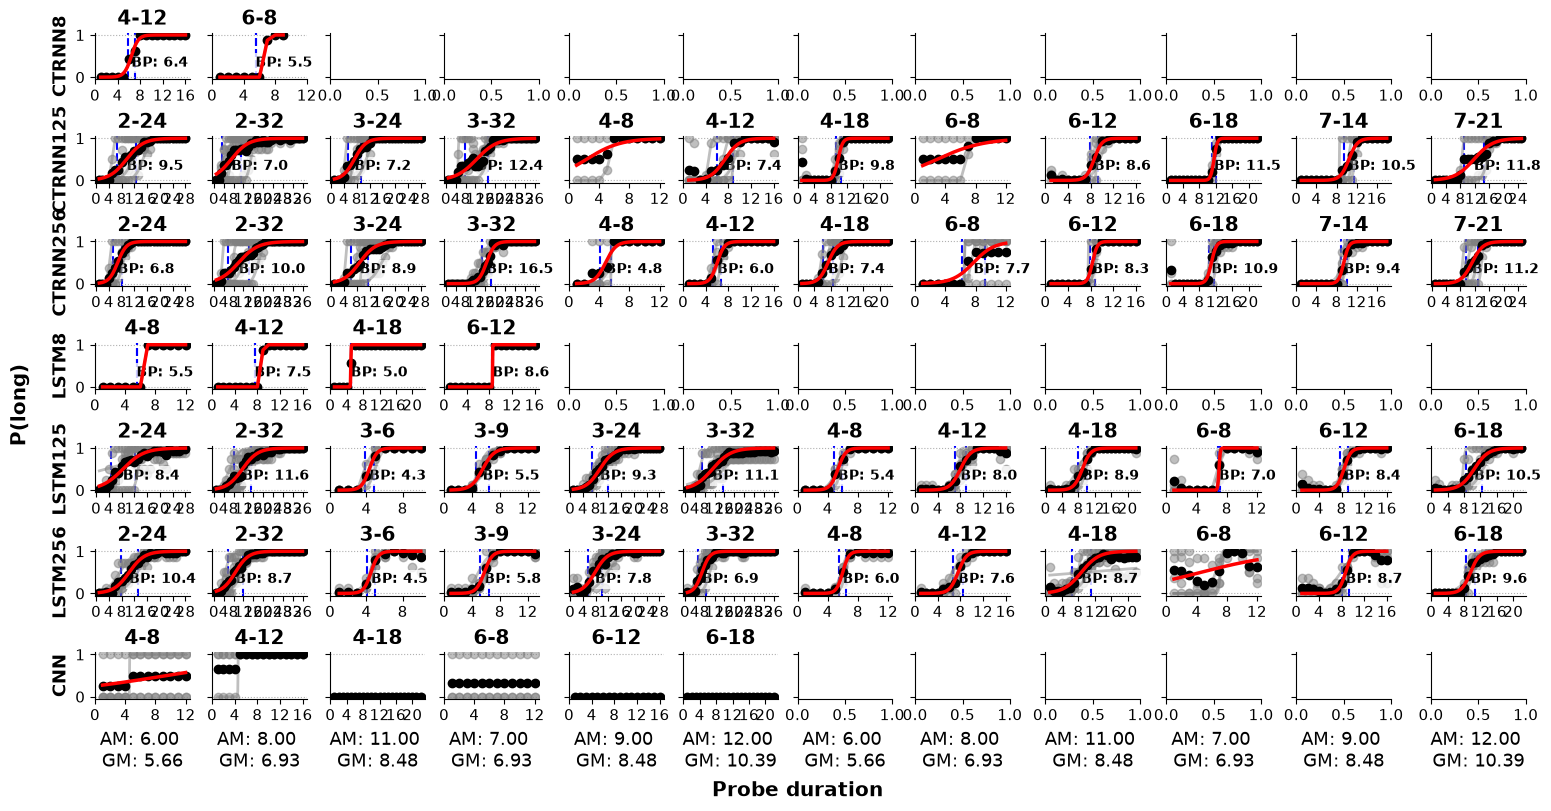

In [16]:
# psychometric_curve(delivery_counter_used_history['4-8'])
# todo: remove bp, dl, wf calculations from here 

# all_data = [delivery_counter_used_history_8,delivery_counter_used_history_lstm8,delivery_counter_used_history_256,delivery_counter_used_history_lstm256 ]
# all_labels = ["CTRNN8","LSTM8","CTRNN256","LSTM256"]

# all_data = [delivery_counter_used_history_125, delivery_counter_used_history_lstm125, delivery_counter_used_history_cnn ]
# all_labels = ["CTRNN125","LSTM125","CNN"]

# all_data = [delivery_counter_used_history_125, delivery_counter_used_history_256, delivery_counter_used_history_lstm125, delivery_counter_used_history_lstm256 ]
# all_labels = ["CTRNN125", "CTRNN256","LSTM125","LSTM256"]

all_data = [delivery_counter_used_history_8, delivery_counter_used_history_125, delivery_counter_used_history_256, delivery_counter_used_history_lstm8, delivery_counter_used_history_lstm125, delivery_counter_used_history_lstm256, delivery_counter_used_history_cnn ]
all_labels = ["CTRNN8", "CTRNN125", "CTRNN256","LSTM8","LSTM125","LSTM256","CNN"]

# all_data = [delivery_counter_used_history_125, delivery_counter_used_history_lstm125 ]
# all_labels = ["CTRNN125","LSTM125"]
# fig, ax = plt.subplots(len(all_data), 6, sharey=True, figsize=(9,5.5), constrained_layout=True)
# fig, ax = plt.subplots(len(all_data), 6, sharey=True, figsize=(9,6), constrained_layout=True) # supp
fig, ax = plt.subplots(len(all_data), 12, sharey=True, figsize=(15,8), constrained_layout=True) # new anchors
avg_bp_jnd_wf_df_all = []
mean_wf = []
anchor_to_ax = {}
# avg_pse_dl_wf_df = pd.DataFrame()
# rows = []
for plot_i, data in enumerate(all_data):
    rows = []
    filtered_data = {}
    for outer_k, inner in data.items():
        # if outer_k not in ["4-8","4-12","4-18","6-8","6-12","6-18"]:
        #     continue
        filtered_inner = {k: v for k, v in inner.items() if v}
        if filtered_inner:
            filtered_data[outer_k] = filtered_inner
    for i, (anchor, anchor_data) in enumerate(filtered_data.items()):
        print(anchor)

        if all(not v for v in anchor_data.values()):
            continue
        short = int(anchor.split("-")[0])
        long = int(anchor.split("-")[-1])  
        am = (short+long)/2
        gm = round(np.sqrt(long*short),3)
        bp_ts, dl_ts, wf_ts = [], [], []
    

        participant_plong = get_plong_across_runs(anchor_data, anchor)
        x0_mean, k_mean, bp_mean, t25_mean, t75_mean, jnd_mean = groupmean_psychometric_curve(participant_plong, 
                                                                                              label=anchor, ax=ax[plot_i,i])
        # print(x0_mean, k_mean)
        ax[plot_i, i].grid(axis="y", linestyle=":")
        
        # bp_mean = round(inv_logistic(0.5, x0_mean, k_mean),3)
        # t25_mean = round(inv_logistic(0.25, x0_mean, k_mean),3)
        # t75_mean = round(inv_logistic(0.75, x0_mean, k_mean),3)
        # jnd_mean = round(0.5*(inv_logistic(0.75, x0_mean, k_mean)-inv_logistic(0.25, x0_mean, k_mean)),3)
        # # print(anchor, bp_mean, t25_mean, t75_mean, jnd_mean)
        # bp_mean none - failed soup delivery, bp_mean<0(-100)- failed timing task , jnd<0- not a good s shaped fit 
        if (bp_mean is not None) and (bp_mean>0) and (t25_mean>0) and (t75_mean>0):

            #plot mean bp and jnd range if mean sigmoid exists
            # JND boundaries
            ax[plot_i, i].axvline(
                t25_mean,
                color="blue",
                linestyle="--",
                linewidth=1.5,
                zorder=1,
            )
        
            ax[plot_i, i].axvline(
                t75_mean,
                color="blue",
                linestyle="--",
                linewidth=1.5,
                zorder=1,
            )
        
            # BP label at (BP, 0.5)
            # ax[plot_i, i].text(
            #     bp_mean,
            #     0.5,
            #     f"BP={bp_mean:.1f}",
            #     # color="maroon",
            #     fontsize=10,
            #     fontweight="bold",
            #     ha="left",
            #     va="bottom",
            #     bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=1),
            # )
            ax[plot_i, i].text(bp_mean, 0.5,
                        f"BP: {bp_mean:.1f}",
                        # transform=a.transAxes,
                        fontsize=10,
                        fontweight='bold',
                        va='top',
                        bbox=dict(
                            facecolor='white',
                            edgecolor='none',
                            alpha=0.8,
                            pad=2
                        )
                    )
                    
                    
            
    
        #plot psychometric curve per participant and group mean 
        for ts, data in anchor_data.items():
            x0, k, bp, t25, t75, jnd = psychometric_curve_per_run(data, label=anchor, ax=ax[plot_i,i])

        
            anchor_to_ax[anchor] = ax[plot_i, i]
            # if (x0 == 0) and (k==0):
            # # if (x0 <= 0):
            #     try:
            #         bp = round(((np.min([k for k, v in participant_plong[ts].items() if v>=0.5]) + np.max([k for k, v in participant_plong[ts].items() if v<=0.5]))/2),3) # first check why curve cannot fit. Mostly a step function. manual calculate of bp, dl ,wf 
            #         t25 = (np.min([k for k, v in participant_plong[ts].items() if v>=0.25]) + np.max([k for k, v in participant_plong[ts].items() if v<=0.25]))/2
            #         t75 = (np.min([k for k, v in participant_plong[ts].items() if v>=0.75]) + np.max([k for k, v in participant_plong[ts].items() if v<=0.75]))/2
            #         jnd = round(0.5*(t75-t25),3)
            #     except:
            #         # print("could not process",ts,plot_i)
            #         continue
            # else:
            #     bp = round(inv_logistic(0.5, x0, k),3)
            #     t25 = round(inv_logistic(0.25, x0, k),3)
            #     t75 = round(inv_logistic(0.75, x0, k),3)
            #     jnd = round(0.5*(inv_logistic(0.75, x0, k)-inv_logistic(0.25, x0, k)),3)
    
            if (bp is not None) and (bp>0) and (t25>0) and (t75>0):
                wf = round(jnd/bp,3)
            else:
                wf = np.nan
            # print(anchor, all_labels[plot_i], x0,k,bp,t25,t75,jnd)       
            rows.append({"anchor":anchor, "p_id":ts, "x0":x0, "k":k, "bp":bp, "jnd":jnd, "AM":(short+long)/2, 
                         "GM":round(np.sqrt(long*short),3), "wf":wf, "t25":t25, "t75":t75,
                         "bp_mean": bp_mean, "t25_mean":t25_mean, "t75_mean":t75_mean, "jnd_mean":jnd_mean,
                          "L-S":np.round(long-short,2), "log2(L-S)":np.round(np.log2(long-short),2),
                         "L/S":np.round(long/short,2), "log2(L/S)":np.round(np.log2(long/short),2), "model":all_labels[plot_i]})
        ax[-1,i].set_xlabel(f"AM: {am:.2f} \nGM: {gm:.2f}")

                
    if len(rows) == 0:
        continue
    avg_bp_jnd_wf_df = pd.DataFrame(rows)  
    avg_bp_jnd_wf_df["bp/AM"] = avg_bp_jnd_wf_df["bp"]/avg_bp_jnd_wf_df["AM"]
    avg_bp_jnd_wf_df["bp/GM"] = avg_bp_jnd_wf_df["bp"]/avg_bp_jnd_wf_df["GM"]
    avg_bp_jnd_wf_df["bp-Am-GM"] = np.abs(avg_bp_jnd_wf_df["bp"]-avg_bp_jnd_wf_df["GM"])/np.abs(avg_bp_jnd_wf_df["bp"]-avg_bp_jnd_wf_df["AM"])
    # avg_bp_jnd_wf_df["log2(bp-Am-GM)"] = np.round(np.log2(avg_bp_jnd_wf_df["bp-Am-GM"]),2)
    avg_bp_jnd_wf_df["log2(bp-Am-GM)"] = np.where(avg_bp_jnd_wf_df["bp-Am-GM"] > 0,np.log2(avg_bp_jnd_wf_df["bp-Am-GM"]),np.nan)

    avg_bp_jnd_wf_df["log2(bp-Am-GM)"] = (avg_bp_jnd_wf_df["log2(bp-Am-GM)"].round(2))
    # avg_bp_jnd_wf_df["closer_AM_GM"] = avg_bp_jnd_wf_df.apply(lambda x: "AM" if np.abs(x["pse/AM"] - 1) < np.abs(x["pse/GM"] - 1) else "GM", axis=1 )
    # mean_df = avg_bp_jnd_wf_df[["anchor","bp","t25", "t75", "AM","GM","model"]].groupby(["anchor","model"]).mean().reset_index()[["anchor","model","bp","t25", "t75", "AM","GM"]]
    
    # anchor_to_ax[anchor] = ax[plot_i, i]
    # for _, row in mean_df.iterrows():
    #     anchor = row["anchor"]
        
    #     if anchor not in anchor_to_ax:
    #         continue
        
    #     a = anchor_to_ax[anchor]
        
    #     bp = row["bp"]
    #     am = row["AM"]
    #     gm = row["GM"]
    
    #     # a.axvline(pse, color='maroon', linewidth=1.5, label='PSE')
    #     # a.axvline(am, color='blue', linestyle='--')
    #     # a.axvline(gm, color='green', linestyle=':')
    #     if bp <=0:
    #         continue

    #     a.text(
    #         bp_mean, 0.5,
    #         f"BP: {bp:.1f}",
    #         transform=a.transAxes,
    #         fontsize=10,
    #         fontweight='bold',
    #         va='top',
    #         bbox=dict(
    #             facecolor='white',
    #             edgecolor='none',
    #             alpha=0.8,
    #             pad=2
    #         )
    #     )


    
    ax[plot_i,0].set_ylabel(all_labels[plot_i],fontweight='bold')
    
    
    avg_bp_jnd_wf_df_all.append(avg_bp_jnd_wf_df)
fig.supxlabel("Probe duration",fontweight='bold')
fig.supylabel("P(long)",x=-0.025,fontweight='bold')
# plt.tight_layout()
# plt.subplots_adjust(hspace=0.8)
# plt.savefig("chronocooked_psychometric.pdf", bbox_inches='tight')
# plt.savefig("chronocooked_psychometric_supp.pdf", bbox_inches='tight')
plt.show()

# Task performance 

In [17]:
avg_bp_jnd_wf_df_all = pd.concat(avg_bp_jnd_wf_df_all)

In [18]:
# number of succeful soup deliveries , ctrnn totla runs = 12 
avg_bp_jnd_wf_df_all.groupby("model")["anchor"].count(), 

model
CNN         24
CTRNN125    41
CTRNN256    47
CTRNN8       2
LSTM125     48
LSTM256     48
LSTM8        4
Name: anchor, dtype: int64

In [19]:
# number of successful timing tasks 
avg_bp_jnd_wf_df_all[(~avg_bp_jnd_wf_df_all["bp"].isna()) & (avg_bp_jnd_wf_df_all["bp"]>0)].groupby("model")["anchor"].count()

model
CNN          2
CTRNN125    36
CTRNN256    45
CTRNN8       2
LSTM125     48
LSTM256     47
LSTM8        4
Name: anchor, dtype: int64

# bp, wf and spread 

In [22]:
# avg_bp_jnd_wf_df_all = pd.concat(avg_bp_jnd_wf_df_all)
avg_bp_jnd_wf_df_all["log2(AM)"] = np.log2(avg_bp_jnd_wf_df_all["AM"])
avg_bp_jnd_wf_df_all["log2(GM)"] = np.log2(avg_bp_jnd_wf_df_all["GM"])

In [23]:
avg_bp_jnd_wf_df_all[:50]

,anchor,p_id,x0,k,bp,jnd,AM,GM,wf,t25,...,log2(L-S),L/S,log2(L/S),model,bp/AM,bp/GM,bp-Am-GM,log2(bp-Am-GM),log2(AM),log2(GM)
0,4-12,1-950000,6.428048,0.616766,6.428,0.678,8.0,6.928,0.105,5.750,...,3.00,3.00,1.58,CTRNN8,0.803500,0.927829,0.318066,-1.65,3.000000,2.792439
1,6-8,1-950000,0.000000,0.000000,5.500,0.000,7.0,6.928,0.000,5.500,...,1.00,1.33,0.42,CTRNN8,0.785714,0.793880,0.952000,-0.07,2.807355,2.792439
0,2-24,1-950000,0.000000,0.000000,-100.000,-100.000,13.0,6.928,NaN,-100.000,...,4.46,12.00,3.58,CTRNN125,-7.692308,-14.434180,0.946265,-0.08,3.700440,2.792439
1,2-24,2-950000,11.538438,1.551023,11.538,1.704,13.0,6.928,0.148,9.834,...,4.46,12.00,3.58,CTRNN125,0.887538,1.665416,3.153215,1.66,3.700440,2.792439
2,2-24,3-950000,14.664685,1.245320,14.665,1.368,13.0,6.928,0.093,13.297,...,4.46,12.00,3.58,CTRNN125,1.128077,2.116773,4.646847,2.22,3.700440,2.792439
3,2-24,4-950000,0.000000,0.000000,4.000,0.500,13.0,6.928,0.125,3.500,...,4.46,12.00,3.58,CTRNN125,0.307692,0.577367,0.325333,-1.62,3.700440,2.792439
4,2-32,1-950000,4.163158,1.447997,4.163,1.591,17.0,8.000,0.382,2.572,...,4.91,16.00,4.00,CTRNN125,0.244882,0.520375,0.298902,-1.74,4.087463,3.000000
5,2-32,2-950000,3.499997,0.476853,3.500,0.524,17.0,8.000,0.150,2.976,...,4.91,16.00,4.00,CTRNN125,0.205882,0.437500,0.333333,-1.58,4.087463,3.000000
6,2-32,3-950000,14.985639,0.764155,14.986,0.840,17.0,8.000,0.056,14.146,...,4.91,16.00,4.00,CTRNN125,0.881529,1.873250,3.468719,1.79,4.087463,3.000000
7,2-32,4-950000,6.831506,0.507793,6.832,0.558,17.0,8.000,0.082,6.274,...,4.91,16.00,4.00,CTRNN125,0.401882,0.854000,0.114870,-3.12,4.087463,3.000000


In [110]:
np.where(significance_df_bp.isna())
# significance_df_bp[["model","bp","anchor"]][0:50]

(array([], dtype=int64), array([], dtype=int64))

# BP regularities 

In [24]:
from scipy.stats import ttest_ind
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import shapiro, levene
from statsmodels.stats.diagnostic import het_breuschpagan


In [ ]:
# BP is sub-arithmatic - BP/AM vs log(spread)
# BP/AM does not change with AM for a specific spread 
# BP transitions from sub-geometric to sub-aritmatic with spread 

In [25]:
filtered_avg_bp_jnd_wf_df_all = avg_bp_jnd_wf_df_all[(~avg_bp_jnd_wf_df_all["bp"].isna()) & (avg_bp_jnd_wf_df_all["bp"]>0)]
filtered_avg_bp_jnd_wf_df_all = filtered_avg_bp_jnd_wf_df_all[(filtered_avg_bp_jnd_wf_df_all["t25"]>0) & 
    (filtered_avg_bp_jnd_wf_df_all["t75"]>0)]
filtered_avg_bp_jnd_wf_df_all = filtered_avg_bp_jnd_wf_df_all[filtered_avg_bp_jnd_wf_df_all["model"].str.contains("125|256|8", na=False)]
filtered_avg_bp_jnd_wf_df_all

,anchor,p_id,x0,k,bp,jnd,AM,GM,wf,t25,...,log2(L-S),L/S,log2(L/S),model,bp/AM,bp/GM,bp-Am-GM,log2(bp-Am-GM),log2(AM),log2(GM)
0,4-12,1-950000,6.428048,0.616766,6.428,0.678,8.0,6.928,0.105,5.750,...,3.00,3.00,1.58,CTRNN8,0.803500,0.927829,0.318066,-1.65,3.000000,2.792439
1,6-8,1-950000,0.000000,0.000000,5.500,0.000,7.0,6.928,0.000,5.500,...,1.00,1.33,0.42,CTRNN8,0.785714,0.793880,0.952000,-0.07,2.807355,2.792439
1,2-24,2-950000,11.538438,1.551023,11.538,1.704,13.0,6.928,0.148,9.834,...,4.46,12.00,3.58,CTRNN125,0.887538,1.665416,3.153215,1.66,3.700440,2.792439
2,2-24,3-950000,14.664685,1.245320,14.665,1.368,13.0,6.928,0.093,13.297,...,4.46,12.00,3.58,CTRNN125,1.128077,2.116773,4.646847,2.22,3.700440,2.792439
3,2-24,4-950000,0.000000,0.000000,4.000,0.500,13.0,6.928,0.125,3.500,...,4.46,12.00,3.58,CTRNN125,0.307692,0.577367,0.325333,-1.62,3.700440,2.792439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,6-12,4-950000,7.897850,1.296763,7.898,1.425,9.0,8.485,0.180,6.473,...,2.58,2.00,1.00,LSTM256,0.877556,0.930819,0.532668,-0.91,3.169925,3.084915
44,6-18,1-950000,9.177800,0.996005,9.178,1.094,12.0,10.392,0.119,8.084,...,3.58,3.00,1.58,LSTM256,0.764833,0.883179,0.430191,-1.22,3.584963,3.377401
45,6-18,2-950000,9.878752,1.796379,9.879,1.974,12.0,10.392,0.200,7.905,...,3.58,3.00,1.58,LSTM256,0.823250,0.950635,0.241867,-2.05,3.584963,3.377401
46,6-18,3-950000,9.026582,0.578936,9.027,0.636,12.0,10.392,0.070,8.391,...,3.58,3.00,1.58,LSTM256,0.752250,0.868649,0.459132,-1.12,3.584963,3.377401


# combine architecutes data?

In [38]:
# in the paper we include only significance results between 125 and 256. - should be corrected to include pairwise test but sample size of mem size 8 is very small
# annova rsults can solve the multi memory issue. replace p values in paper 
# BP - is there a significant difference between models of the same architecutr 
performance_col = "bp"
# performance_col = "bp-Am-GM"

filtered_avg_bp_jnd_wf_df_all = avg_bp_jnd_wf_df_all[(~avg_bp_jnd_wf_df_all["bp"].isna()) & (avg_bp_jnd_wf_df_all["bp"]>0)]
filtered_avg_bp_jnd_wf_df_all = filtered_avg_bp_jnd_wf_df_all[(filtered_avg_bp_jnd_wf_df_all["t25"]>0) & 
    (filtered_avg_bp_jnd_wf_df_all["t75"]>0)]
filtered_avg_bp_jnd_wf_df_all = filtered_avg_bp_jnd_wf_df_all[filtered_avg_bp_jnd_wf_df_all["model"].str.contains("125|256", na=False)]


for arch in ["LSTM", "CTRNN"]:
    print(arch)
    significance_df_bp = filtered_avg_bp_jnd_wf_df_all
    significance_df_bp["architecture"] = significance_df_bp.apply(lambda x: x["model"][0:4] if "LSTM" in x["model"] else x["model"][0:5], axis=1).astype("category")
    significance_df_bp["memory_size"] = significance_df_bp.apply(lambda x: x["model"][4:] if "LSTM" in x["model"] else x["model"][5:], axis=1).astype("category")
    significance_df_bp["anchor"] = significance_df_bp["anchor"].astype("category")
    significance_df_bp = significance_df_bp.rename(columns={performance_col:"performance"})
    df = significance_df_bp[significance_df_bp["architecture"] == arch]
    # print(df[["bp", "AM", "GM", "performance"]].describe())
    # print(df["performance"].isna().sum())
    # for grp, data in df.groupby("model"):
    #     if "125" in grp:
    #         grp1_data = data[performance_col]
    #     if "256" in grp:
    #         grp2_data = data[performance_col]

    # print("test equal variance")
    # stat, p = levene(grp1_data,grp2_data)

    # print("stat =", stat)
    # print("p  =", p)

    model = smf.ols(
        "performance ~ C(memory_size) + C(anchor)",
        data=df
    ).fit()

    stat, p = shapiro(model.resid)
    print("Shapiro-Wilk:", stat, p)
    print("data size",df.groupby("model")["p_id"].count())

    df["residual"] = model.resid
    res_125 = df[df["memory_size"] == "125"]["residual"]
    res_256 = df[df["memory_size"] == "256"]["residual"]
    
    stat, p = levene(res_125, res_256, center="median")
    
    print(f"Levene: W={stat:.3f}, p={p:.3f}")
       
    # print(sm.stats.anova_lm(model, typ=2))
    # print(model.t_test("C(memory_size)[T.256]"))
    # print(model.summary())
    anova = sm.stats.anova_lm(model, typ=2)
    # print(model.t_test("C(memory_size)[T.256]"))
    print(anova)
    

# # filtered_avg_bp_jnd_wf_df_all.groupby(["model"])[["bp"]].describe()    

LSTM
Shapiro-Wilk: 0.9604688558668528 0.006565347799266208
data size model
LSTM125    47
LSTM256    46
Name: p_id, dtype: int64
Levene: W=0.813, p=0.370
                    sum_sq    df         F        PR(>F)
C(memory_size)    9.176222   1.0  2.649977  1.074837e-01
C(anchor)       400.143646  13.0  8.888957  4.163530e-10
Residual        277.020389  80.0       NaN           NaN
CTRNN
Shapiro-Wilk: 0.9528633977316493 0.0047038464777569835
data size model
CTRNN125    36
CTRNN256    45
Name: p_id, dtype: int64
Levene: W=1.333, p=0.252
                    sum_sq    df         F    PR(>F)
C(memory_size)    0.332518   1.0  0.033303  0.855740
C(anchor)       428.674625  13.0  3.302598  0.001128
Residual        678.949685  68.0       NaN       NaN


/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 11
  warnings.warn('covariance of constraints does not have full '
/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 11
  warnings.warn('covariance of constraints does not have full '


# significant difference between architecutre?

In [175]:
# # BP - is there a significant difference between models of the same architecutr 
# performance_col = "bp"
# # performance_col = "bp-Am-GM"

# filtered_avg_bp_jnd_wf_df_all = avg_bp_jnd_wf_df_all[(~avg_bp_jnd_wf_df_all["bp"].isna()) & (avg_bp_jnd_wf_df_all["bp"]>0)]
# filtered_avg_bp_jnd_wf_df_all = filtered_avg_bp_jnd_wf_df_all[(filtered_avg_bp_jnd_wf_df_all["t25"]>0) & 
#     (filtered_avg_bp_jnd_wf_df_all["t75"]>0)]
# filtered_avg_bp_jnd_wf_df_all = filtered_avg_bp_jnd_wf_df_all[filtered_avg_bp_jnd_wf_df_all["model"].str.contains("125|256", na=False)]

# significance_df_bp = filtered_avg_bp_jnd_wf_df_all
# significance_df_bp["architecture"] = significance_df_bp.apply(lambda x: x["model"][:-3], axis=1).astype("category")
# significance_df_bp["memory_size"] = significance_df_bp.apply(lambda x: x["model"][-3:], axis=1).astype("category")
# significance_df_bp["anchor"] = significance_df_bp["anchor"].astype("category")
# significance_df_bp = significance_df_bp.rename(columns={performance_col:"performance"})

# model = smf.ols(
#     "performance ~ C(architecture) + C(anchor)",
#     data=significance_df_bp
# ).fit(cov_type="HC3")  # added becuase var not equal 

# # Normality
# stat, p = shapiro(model.resid)
# print("Shapiro-Wilk:", stat, p)

# # Equal variance between architectures
# df = significance_df_bp.copy()
# df["residual"] = model.resid

# res_lstm = df[df["architecture"] == "LSTM"]["residual"]
# res_ctrnn = df[df["architecture"] == "CTRNN"]["residual"]

# stat, p = levene(res_lstm, res_ctrnn, center="median")
# print(f"Levene: W={stat:.3f}, p={p:.3f}")

# # Architecture effect, controlling for anchor
# print(model.t_test("C(architecture)[T.LSTM]"))

Shapiro-Wilk: 0.9444395803883479 2.6108523885978616e-06
Levene: W=11.548, p=0.001
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.1797      0.486      0.370      0.711      -0.772       1.132


In [34]:
avg_bp_jnd_wf_df_all["anchor"].unique()

<ArrowStringArray>
['4-12',  '6-8', '2-24', '2-32', '3-24', '3-32',  '4-8', '4-18', '6-12',
 '6-18', '7-14', '7-21',  '3-6',  '3-9']
Length: 14, dtype: str

CTRNN125 36
data size model
CTRNN125    36
Name: p_id, dtype: int64
CTRNN256 45
data size model
CTRNN256    45
Name: p_id, dtype: int64
LSTM125 48
data size model
LSTM125    48
Name: p_id, dtype: int64
LSTM256 47
data size model
LSTM256    47
Name: p_id, dtype: int64


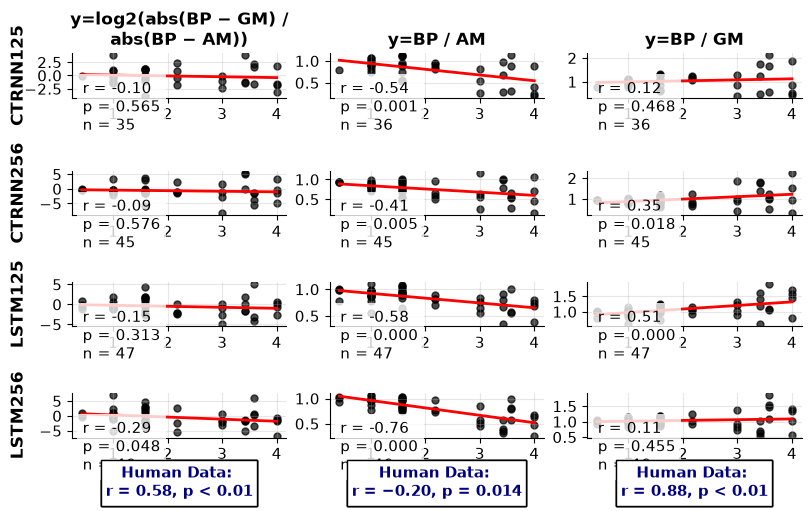

In [46]:
# from matplotlib.ticker import MaxNLocator
# models = ["CTRNN125", "LSTM125"]
# models = ["CTRNN125","CTRNN256", "LSTM125","LSTM256"]
models = ["LSTM","CTRNN"]

plots_y = [
    ("log2(bp-Am-GM)", "log2(abs(BP − GM) /\nabs(BP − AM))"),
    ("bp/AM", "BP / AM"),
    ("bp/GM", "BP / GM"),
    # ("bp/GM", "BP / GM"),
]

plots_x = [("log2(L/S)","log2(L/S)"), ("log2(L/S)","log2(L/S)"),
           ("log2(L/S)","log2(L/S)"),
           # ("log2(GM)", "log2(GM)")
          ]

fig, axes = plt.subplots(
    len(models),
    len(plots_y),
    figsize=(8,5),
    squeeze=False,
    constrained_layout=True
)
# fig.subplots_adjust(
#     wspace=0.7,  # space between columns
#     hspace= 1.2   # space between rows
# )



human_stats = {
    0: ("0.58", "< 0.01"),
    1: ("−0.20", "= 0.014"),
    2: ("0.88", "< 0.01"),
    3: ("-0.156", "0.38")
}

for r, model in enumerate(models):

    # filter for successful timing tasks 
    filtered_avg_bp_jnd_wf_df_all = avg_bp_jnd_wf_df_all[(~avg_bp_jnd_wf_df_all["bp"].isna()) & (avg_bp_jnd_wf_df_all["bp"]>0)]
    
    # filter for model data 
    # df_model = filtered_avg_bp_jnd_wf_df_all[filtered_avg_bp_jnd_wf_df_all["model"] == model]
    filtered_avg_bp_jnd_wf_df_all = filtered_avg_bp_jnd_wf_df_all[filtered_avg_bp_jnd_wf_df_all["model"].str.contains("125|256", na=False)]

    df_model = filtered_avg_bp_jnd_wf_df_all[filtered_avg_bp_jnd_wf_df_all["model"].str.contains(model)]
    
    print(model, len(df_model))  # check number of points
    print("data size",df_model.groupby("model")["p_id"].count())

    for c, (ycol, ylabel) in enumerate(plots_y):
        xcol, xlabel = plots_x[c]

        ax = axes[r, c]

        # remove invalid values
        df_model = df_model[(df_model["bp"]>0) & (df_model["t25"]>0) & (df_model["t75"]>0)]

        if xcol == "log2(GM)":
            df_model = df_model[np.isclose(df_model["L/S"], 2)]
        
        plot_df = df_model[
            [xcol, ycol]
        ].replace([np.inf, -np.inf], np.nan).dropna()


        x = plot_df[xcol].to_numpy()
        y = plot_df[ycol].to_numpy()

        # plot individual points
        ax.scatter(
            x,
            y,
            color="black",
            s=25,
            alpha=0.7
        )
        # ax.yaxis.set_major_locator(MaxNLocator(integer=True))

        # regression
        if len(x) > 1:

            slope, intercept, rval, pval, stderr = linregress(x, y)

            x_fit = np.linspace(
                np.min(x),
                np.max(x),
                100
            )

            y_fit = intercept + slope * x_fit

            ax.plot(
                x_fit,
                y_fit,
                color="red",
                linewidth=2
            )

            ax.text(
                0.05,
                0.4,
                f"r = {rval:.2f}\n"
                f"p = {pval:.3f}\n"
                # f"s = {slope:.2f}\n"
                f"n = {len(x)}",
                transform=ax.transAxes,
                va="top",
                fontsize=11,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.8
                )
            )
        hr, hp = human_stats[c]

        axes[-1, c].text(
            0.5,
            -0.6,
            f"Human Data: \nr = {hr}, p {hp}",
            transform=axes[-1, c].transAxes,
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold",
            color="navy",
            bbox=dict(
                facecolor="white",
                edgecolor="black",
                boxstyle="square,pad=0.3",
            )
        )
        axes[0,c].set_title(f"y={ylabel}", fontsize=12, fontweight="bold")
        # ax.set_ylabel(ylabel, fontweight="bold")
        if r == len(models)-1:
            ax.set_xlabel(xlabel, fontweight="bold")
        ax.grid(alpha=0.3)

        # if r == 0:
        #     ax.set_title(ylabel, fontweight="bold")

    # y axis labels
    # # Get the vertical midpoint between the two rows
    # for c, (ycol, ylabel) in enumerate(plots):
    
    #     top_pos = axes[0, c].get_position()
    #     bottom_pos = axes[-1, c].get_position()
    
    #     y_middle = (
    #         bottom_pos.y0 + top_pos.y1
    #     ) / 2
    
    #     fig.text(
    #         top_pos.x0 - 0,
    #         y_middle,
    #         ylabel,
    #         ha="center",
    #         va="center",
    #         rotation=90,
    #         fontsize=11,
    #         fontweight="bold"
    #     )

    
    # model labels
    axes[r, 0].text(
        -0.25,
        0.5,
        model,
        transform=axes[r, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )


# fig.supxlabel("log₂(L/S)", y=0.08, fontweight="bold")
# plt.savefig("bp_plots_supp.pdf", bbox_inches='tight')
plt.savefig("bp_plots.pdf", bbox_inches='tight')
plt.show()

In [40]:
# # import statsmodels.formula.api as smf

# # significant different relationship between bp/am and spread between the two arch 
# x_model1 = avg_bp_jnd_wf_df_all[avg_bp_jnd_wf_df_all["model"].isin(["LSTM125","LSTM256","LSTM8"])]["log2(L/S)"]
# y_model1 = avg_bp_jnd_wf_df_all[avg_bp_jnd_wf_df_all["model"].isin(["LSTM125","LSTM256","LSTM8"])]["bp/GM"]

# x_model2 = avg_bp_jnd_wf_df_all[avg_bp_jnd_wf_df_all["model"].isin(["CTRNN125","CTRNN256","CTRNN8"])]["log2(L/S)"]
# y_model2 = avg_bp_jnd_wf_df_all[avg_bp_jnd_wf_df_all["model"].isin(["CTRNN125","CTRNN256","CTRNN8"])]["bp/GM"]


# df = pd.DataFrame({
#     "x": np.concatenate([x_model1, x_model2]),
#     "y": np.concatenate([y_model1, y_model2]),
#     "model": ["LSTM"] * len(x_model1) + ["CTRNN"] * len(x_model2)
# })

# model = smf.ols(
#     "y ~ x * C(model)",
#     data=df
# ).fit()

# print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     3.518
Date:                Fri, 21 Aug 2026   Prob (F-statistic):             0.0162
Time:                        10:36:21   Log-Likelihood:                -464.15
No. Observations:                 188   AIC:                             936.3
Df Residuals:                     184   BIC:                             949.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.2470      0

In [38]:
# significance test to check if lstm significanltly differ from ctrnn


dfs = []

for arch in ["CTRNN", "LSTM"]:

    df_arch = avg_bp_jnd_wf_df_all[
        avg_bp_jnd_wf_df_all["model"].str.startswith(arch)
    ].copy()

    # Remove invalid values
    df_arch = df_arch[
        (df_arch["bp"] > 0) &
        (df_arch["t25"] > 0) &
        (df_arch["t75"] > 0)
    ]

    df_arch["architecture"] = arch

    dfs.append(
        df_arch[
            ["log2(L/S)", "bp/AM", "architecture"]
        ]
    )

df_compare = pd.concat(dfs)

df_compare = (
    df_compare
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# ---------------------------------------------------------
# Regression:
# WF ~ log2(L/S) * architecture
# ---------------------------------------------------------

model = smf.ols(
    'Q("bp/AM") ~ Q("log2(L/S)") * C(architecture)',
    data=df_compare
).fit()

print(model.summary())

# ---------------------------------------------------------
# Extract architecture × log2(L/S) interaction
# ---------------------------------------------------------

term = 'Q("log2(L/S)"):C(architecture)[T.LSTM]'

print("\nArchitecture × log2(L/S):")
print(f"β = {model.params[term]:.4g}")
print(f"p = {model.pvalues[term]:.4f}")

if model.pvalues[term] < 0.05:
    print(
        "→ Significant difference in WF-vs-log2(L/S) "
        "relationship between LSTM and CTRNN."
    )
else:
    print(
        "→ No significant difference in WF-vs-log2(L/S) "
        "relationship between LSTM and CTRNN."
    )

                            OLS Regression Results                            
Dep. Variable:             Q("bp/AM")   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.318
Method:                 Least Squares   F-statistic:                     28.85
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           3.20e-15
Time:                        10:34:33   Log-Likelihood:                 52.724
No. Observations:                 180   AIC:                            -97.45
Df Residuals:                     176   BIC:                            -84.68
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [177]:
# import pandas as pd
# import statsmodels.formula.api as smf
# plots = [
#     ("bp/AM", "BP / AM"),
# ]

# architectures = ["CTRNN", "LSTM"]

# for ycol, ylabel in plots:

#     dfs = []

#     for arch in architectures:

#         df_arch = avg_bp_jnd_wf_df_all[
#             avg_bp_jnd_wf_df_all["model"].str.startswith(arch)
#         ].copy()

#         # Keep valid observations
#         df_arch = df_arch[
#             (df_arch["bp"] > 0) &
#             (df_arch["t25"] > 0) &
#             (df_arch["t75"] > 0)
#         ]

#         df_arch["architecture"] = arch

#         dfs.append(df_arch[
#             ["log2(L/S)", ycol, "architecture"]
#         ])

#     df_compare = pd.concat(dfs)

#     df_compare = (
#         df_compare
#         .replace([np.inf, -np.inf], np.nan)
#         .dropna()
#     )

#     # Architecture × predictor interaction
#     model = smf.ols(
#         f'Q("{ycol}") ~ Q("log2(L/S)") * C(architecture)',
#         data=df_compare
#     ).fit()

#     print("\n", ylabel)
#     print(model.summary())

# weber ratio

# combine architecture?

In [41]:
 
# BP - is there a significant difference between models of the same architecutr 
performance_col = "wf"
# performance_col = "bp-Am-GM"

filtered_avg_bp_jnd_wf_df_all = avg_bp_jnd_wf_df_all[(~avg_bp_jnd_wf_df_all["bp"].isna()) & (avg_bp_jnd_wf_df_all["bp"]>0)]
filtered_avg_bp_jnd_wf_df_all = filtered_avg_bp_jnd_wf_df_all[(filtered_avg_bp_jnd_wf_df_all["t25"]>0) & 
    (filtered_avg_bp_jnd_wf_df_all["t75"]>0)]
# filtered_avg_bp_jnd_wf_df_all = filtered_avg_bp_jnd_wf_df_all[filtered_avg_bp_jnd_wf_df_all["model"].str.contains("125|256", na=False)]

filtered_avg_bp_jnd_wf_df_all = filtered_avg_bp_jnd_wf_df_all[filtered_avg_bp_jnd_wf_df_all["model"].str.contains("125|256", na=False)]



for arch in ["LSTM", "CTRNN"]:
    print(arch)
    significance_df_bp = filtered_avg_bp_jnd_wf_df_all
    significance_df_bp["architecture"] = significance_df_bp.apply(lambda x: x["model"][0:4] if "LSTM" in x["model"] else x["model"][0:5], axis=1).astype("category")
    significance_df_bp["memory_size"] = significance_df_bp.apply(lambda x: x["model"][4:] if "LSTM" in x["model"] else x["model"][5:], axis=1).astype("category")
    significance_df_bp["anchor"] = significance_df_bp["anchor"].astype("category")
    significance_df_bp = significance_df_bp.rename(columns={performance_col:"performance"})
    df = significance_df_bp[significance_df_bp["architecture"] == arch]
    # print(df[["bp", "AM", "GM", "performance"]].describe())
    # print(df["performance"].isna().sum())
    # for grp, data in df.groupby("model"):
    #     if "125" in grp:
    #         grp1_data = data[performance_col]
    #     if "256" in grp:
    #         grp2_data = data[performance_col]

    # print("test equal variance")
    # stat, p = levene(grp1_data,grp2_data)

    # print("stat =", stat)
    # print("p  =", p)

    model = smf.ols(
        "performance ~ C(memory_size) + C(anchor)",
        data=df
    ).fit()

    stat, p = shapiro(model.resid)
    print("Shapiro-Wilk:", stat, p)
    print("data size",df.groupby("model")["p_id"].count())

    df["residual"] = model.resid
    res_125 = df[df["memory_size"] == "125"]["residual"]
    res_256 = df[df["memory_size"] == "256"]["residual"]
    
    stat, p = levene(res_125, res_256, center="median")
    
    print(f"Levene: W={stat:.3f}, p={p:.3f}")
       
    # print(sm.stats.anova_lm(model, typ=2))
    # print(model.t_test("C(memory_size)[T.256]"))
    # print(model.summary())
    anova = sm.stats.anova_lm(model, typ=2)
    # print(model.t_test("C(memory_size)[T.256]"))
    print(anova)
    

# # filtered_avg_bp_jnd_wf_df_all.groupby(["model"])[["bp"]].describe()    

LSTM
Shapiro-Wilk: 0.921135441176018 3.08508077632408e-05
data size model
LSTM125    47
LSTM256    46
Name: p_id, dtype: int64
Levene: W=0.085, p=0.772
                  sum_sq    df         F        PR(>F)
C(memory_size)  0.002544   1.0  0.561373  4.559052e-01
C(anchor)       0.443517  13.0  7.528366  1.004078e-08
Residual        0.362541  80.0       NaN           NaN
CTRNN
Shapiro-Wilk: 0.8671019992489369 5.591311851995998e-07
data size model
CTRNN125    36
CTRNN256    45
Name: p_id, dtype: int64
Levene: W=0.129, p=0.720
                  sum_sq    df         F    PR(>F)
C(memory_size)  0.000450   1.0  0.181384  0.671531
C(anchor)       0.125351  13.0  3.883539  0.000228
Residual        0.168836  68.0       NaN       NaN


/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 11
  warnings.warn('covariance of constraints does not have full '
/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 11
  warnings.warn('covariance of constraints does not have full '


LSTM 93
CTRNN 81


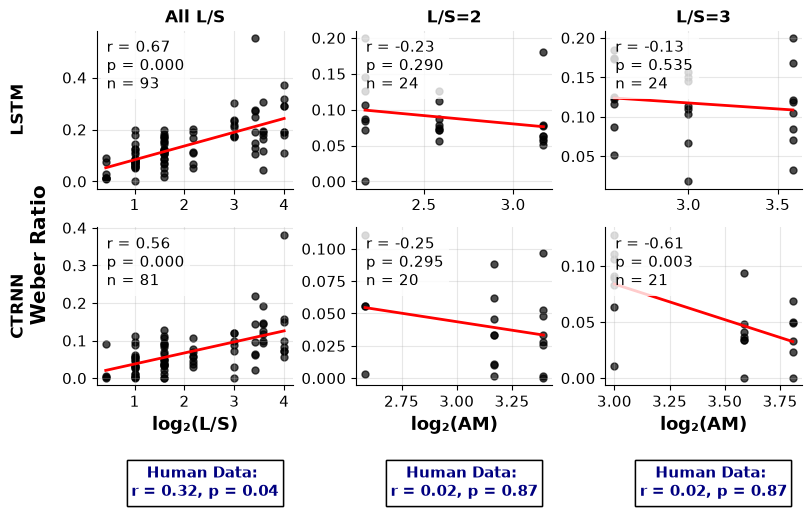

In [43]:
# wf 

# models = ["CTRNN125","CTRNN256", "LSTM125","LSTM256"]
models = ["LSTM","CTRNN"]
# log_spread = "log2(L-S)"
# spread = "L-S"
log_spread = "log2(L/S)"
spread = "L/S"
fig, axes = plt.subplots(
    len(models),
    3,
    figsize=(8,5),
    squeeze=False,
    constrained_layout=True
)

human_stats = {
    0: (0.323, 0.04),
    1: (0.017, 0.87),
    2: (0.017, 0.87),
}

plots = [
    (log_spread, "wf", "log₂(L/S)", "WF"),
    ("log2(AM)", "wf", "log₂(AM)", "WF"),
    ("log2(AM)", "wf", "log₂(AM)", "WF"),
]


for r, model in enumerate(models):
    filtered_avg_bp_jnd_wf_df_all = avg_bp_jnd_wf_df_all[(~avg_bp_jnd_wf_df_all["bp"].isna()) & (avg_bp_jnd_wf_df_all["bp"]>0)]
    
    # filter for model data 
    # df_model = filtered_avg_bp_jnd_wf_df_all[filtered_avg_bp_jnd_wf_df_all["model"] == model]
    filtered_avg_bp_jnd_wf_df_all = filtered_avg_bp_jnd_wf_df_all[filtered_avg_bp_jnd_wf_df_all["model"].str.contains("125|256", na=False)]


    # df_model = avg_bp_jnd_wf_df_all[avg_bp_jnd_wf_df_all["model"] == model]
    df_model = filtered_avg_bp_jnd_wf_df_all[filtered_avg_bp_jnd_wf_df_all["model"].str.contains(model)]
    
    # remove invalid values
    df_model = df_model[(df_model["bp"]>0) & (df_model["t25"]>0) & (df_model["t75"]>0)]

    print(model, len(df_model))

    for c, (xcol, ycol, xlabel, ylabel) in enumerate(plots):

        ax = axes[r, c]

        # Filters
        if c == 0:
            plot_df = df_model.copy()

        elif c == 1:
            plot_df = df_model[
                np.isclose(df_model[spread], 2)
            ]

        elif c == 2:
            plot_df = df_model[
                np.isclose(df_model[spread], 3)
            ]
            # plot_df = df_model[df_model[spread]==3]

        # remove invalid values
        # plot_df = plot_df[plot_df[ycol]<0.9]

        plot_df = plot_df[
            [xcol, ycol]
        ].replace([np.inf, -np.inf], np.nan).dropna()


        x = plot_df[xcol].to_numpy()
        y = plot_df[ycol].to_numpy()



        # scatter points
        ax.scatter(
            x,
            y,
            color="black",
            s=25,
            alpha=0.7
        )
        
        axes[0,0].set_title(f"All L/S", fontsize=12, fontweight="bold")
        axes[0,1].set_title(f"L/S=2", fontsize=12, fontweight="bold")
        axes[0,2].set_title(f"L/S=3", fontsize=12, fontweight="bold")

        # regression
        if len(x) > 1:

            slope, intercept, rval, pval, stderr = linregress(x, y)

            x_fit = np.linspace(
                x.min(),
                x.max(),
                100
            )

            y_fit = intercept + slope * x_fit

            ax.plot(
                x_fit,
                y_fit,
                color="red",
                linewidth=2
            )

            ax.text(
                0.05,
                0.95,
                f"r = {rval:.2f}\n"
                f"p = {pval:.3f}\n"
                f"n = {len(x)}",
                transform=ax.transAxes,
                va="top",
                fontsize=11,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.8
                )
            )
            
        hr, hp = human_stats[c]
        axes[-1, c].text(
            0.55,
            -0.5,                       # place below bottom subplot
            f"Human Data: \nr = {hr:.2f}, p = {hp:.2f}",
            transform=axes[-1, c].transAxes,
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold",
            color="navy",
            bbox=dict(
                facecolor="white",
                edgecolor="black",
                boxstyle="square,pad=0.3",
            )
            
        )


         
        axes[-1,c].set_xlabel(xlabel, fontweight="bold")
        # ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        # break
    # break


        # if r == 0:
        #     ax.set_title(xlabel, fontweight="bold")


    axes[r,0].text(
        -0.4,
        0.5,
        model,
        transform=axes[r,0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

fig.supylabel("Weber Ratio", x=0.03, fontweight="bold")
plt.savefig("wf_plots.pdf", bbox_inches='tight')
plt.show()

4-8
4-12
4-18
6-8
6-12
6-18
4-8
4-12
4-18
6-8
6-12
6-18
4-8
4-12
4-18
6-8
6-12
6-18
4-8
4-12
4-18
6-8
6-12
6-18


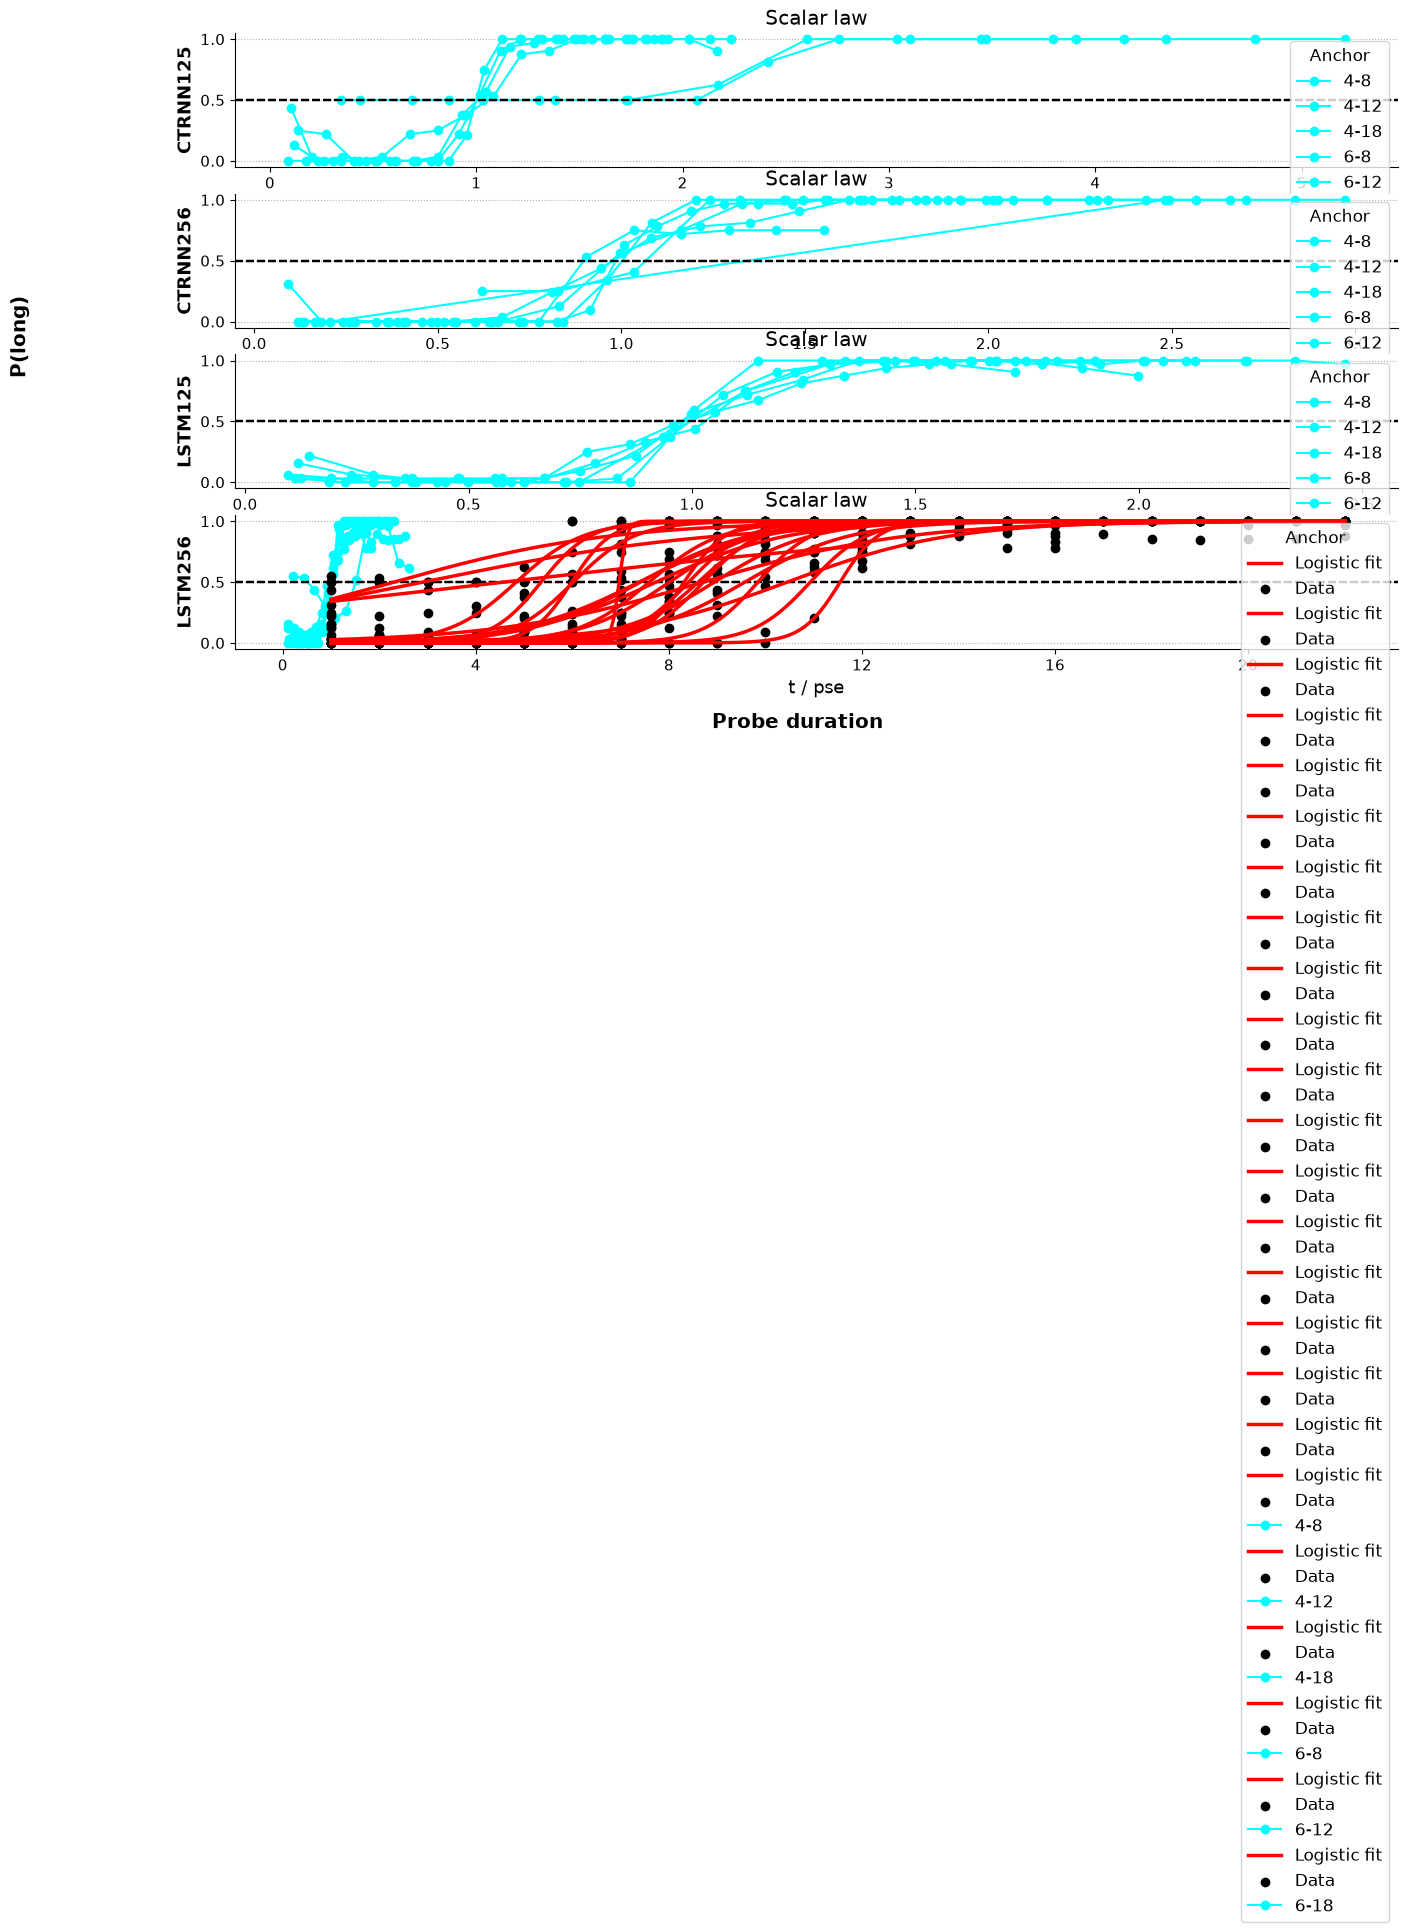

In [215]:
# super imposition
# psychometric_curve(delivery_counter_used_history['4-8'])
# todo: remove bp, dl, wf calculations from here 

# all_data = [delivery_counter_used_history_8,delivery_counter_used_history_lstm8,delivery_counter_used_history_256,delivery_counter_used_history_lstm256 ]
# all_labels = ["CTRNN8","LSTM8","CTRNN256","LSTM256"]

# all_data = [delivery_counter_used_history_125, delivery_counter_used_history_lstm125, delivery_counter_used_history_cnn ]
# all_labels = ["CTRNN125","LSTM125","CNN"]

all_data = [delivery_counter_used_history_125, delivery_counter_used_history_256, delivery_counter_used_history_lstm125, delivery_counter_used_history_lstm256 ]
all_labels = ["CTRNN125", "CTRNN256","LSTM125","LSTM256"]


# all_data = [delivery_counter_used_history_125, delivery_counter_used_history_lstm125 ]
# all_labels = ["CTRNN125","LSTM125"]
# fig, ax = plt.subplots(len(all_data), 6, sharey=True, figsize=(9,5.5), constrained_layout=True)
# fig, ax = plt.subplots(len(all_data), 6, sharey=True, figsize=(9,6), constrained_layout=True) # supp
fig, ax = plt.subplots(len(all_data), 1, sharey=True, figsize=(15,8), constrained_layout=True) # new anchors

# avg_pse_dl_wf_df = pd.DataFrame()
# rows = []
for plot_i, data in enumerate(all_data):
    rows = []
    filtered_data = {}
    for outer_k, inner in data.items():
        if outer_k not in ["4-8","4-12","4-18","6-8","6-12","6-18"]:
            continue
        filtered_inner = {k: v for k, v in inner.items() if v}
        if filtered_inner:
            filtered_data[outer_k] = filtered_inner
    for i in range(1):
        for i_a, (anchor, anchor_data) in enumerate(filtered_data.items()):
            print(anchor)
    
            if all(not v for v in anchor_data.values()):
                continue
            short = int(anchor.split("-")[0])
            long = int(anchor.split("-")[-1])  
            am = (short+long)/2
            gm = round(np.sqrt(long*short),3)
    
        
    
            participant_plong = get_plong_across_runs(anchor_data, anchor)
            participant_plong = {k: {duration: p for duration, p in v.items() if not pd.isna(p)} 
                                 for k, v in participant_plong.items()}
            
            groupmean_superimposition_plot(participant_plong, label=anchor, x_norm="bp", ax=ax[plot_i])
            # print(x0_mean, k_mean)
            ax[plot_i].grid(axis="y", linestyle=":")
            
            
    
        #plot psychometric curve per participant and group mean 
        # for ts, data in anchor_data.items():
        #     psychometric_curve_per_run(data, label=anchor, ax=ax[plot_i,i])

        
        #     anchor_to_ax[anchor] = ax[plot_i, i]
           
    
    ax[plot_i].set_ylabel(all_labels[plot_i],fontweight='bold')
    
    
fig.supxlabel("Probe duration",fontweight='bold')
fig.supylabel("P(long)",x=-0.025,fontweight='bold')
# plt.tight_layout()
# plt.subplots_adjust(hspace=0.8)
# plt.savefig("chronocooked_psychometric.pdf", bbox_inches='tight')
# plt.savefig("chronocooked_psychometric_supp.pdf", bbox_inches='tight')
plt.show()

# Weber ration compare architectures

In [45]:
# significance test to check if lstm significanltly differ from ctrnn

# ---------------------------------------------------------
# Compare LSTM vs CTRNN: WF vs log2(L/S)
# ---------------------------------------------------------

dfs = []

for arch in ["CTRNN", "LSTM"]:
    filtered_avg_bp_jnd_wf_df_all = avg_bp_jnd_wf_df_all[(~avg_bp_jnd_wf_df_all["bp"].isna()) & (avg_bp_jnd_wf_df_all["bp"]>0)]
    
    # filter for model data 
    # df_model = filtered_avg_bp_jnd_wf_df_all[filtered_avg_bp_jnd_wf_df_all["model"] == model]
    filtered_avg_bp_jnd_wf_df_all = filtered_avg_bp_jnd_wf_df_all[filtered_avg_bp_jnd_wf_df_all["model"].str.contains("125|256", na=False)]


    df_arch = filtered_avg_bp_jnd_wf_df_all[
        filtered_avg_bp_jnd_wf_df_all["model"].str.startswith(arch)
    ].copy()

    # Remove invalid values
    df_arch = df_arch[
        (df_arch["bp"] > 0) &
        (df_arch["t25"] > 0) &
        (df_arch["t75"] > 0)
    ]

    df_arch["architecture"] = arch

    dfs.append(
        df_arch[
            ["log2(L/S)", "wf", "architecture"]
        ]
    )

df_compare = pd.concat(dfs)

df_compare = (
    df_compare
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# ---------------------------------------------------------
# Regression:
# WF ~ log2(L/S) * architecture
# ---------------------------------------------------------

model = smf.ols(
    'Q("wf") ~ Q("log2(L/S)") * C(architecture)',
    data=df_compare
).fit()

print(model.summary())

# ---------------------------------------------------------
# Extract architecture × log2(L/S) interaction
# ---------------------------------------------------------

term = 'Q("log2(L/S)"):C(architecture)[T.LSTM]'

print("\nArchitecture × log2(L/S):")
print(f"β = {model.params[term]:.4g}")
print(f"p = {model.pvalues[term]:.4f}")

if model.pvalues[term] < 0.05:
    print(
        "→ Significant difference in WF-vs-log2(L/S) "
        "relationship between LSTM and CTRNN."
    )
else:
    print(
        "→ No significant difference in WF-vs-log2(L/S) "
        "relationship between LSTM and CTRNN."
    )

                            OLS Regression Results                            
Dep. Variable:                Q("wf")   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     59.51
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           2.37e-26
Time:                        14:20:48   Log-Likelihood:                 247.54
No. Observations:                 174   AIC:                            -487.1
Df Residuals:                     170   BIC:                            -474.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [ ]:
# # wf 

# models = ["LSTM125", "CTRNN125"]

# fig, axes = plt.subplots(
#     len(models),
#     3,
#     figsize=(8, 2 * len(models)),
#     squeeze=False,
#     constrained_layout=True
# )

# human_stats = {
#     0: (0.323, 0.04),
#     1: (0.017, 0.87),
#     2: (0.017, 0.87),
# }

# plots = [
#     ("log2(L/S)", "wf", "log₂(L/S)", "WF"),
#     ("log2(AM)", "wf", "log₂(AM) (L/S=2)", "WF"),
#     ("log2(AM)", "wf", "log₂(AM) (L/S=3)", "WF"),
# ]


# for r, model in enumerate(models):

#     df_model = avg_bp_jnd_wf_df_all[avg_bp_jnd_wf_df_all["model"] == model]

#     print(model, len(df_model))

#     for c, (xcol, ycol, xlabel, ylabel) in enumerate(plots):

#         ax = axes[r, c]

#         # Filters
#         if c == 0:
#             plot_df = df_model.copy()

#         elif c == 1:
#             plot_df = df_model[
#                 np.isclose(df_model["L/S"], 2)
#             ]

#         elif c == 2:
#             plot_df = df_model[
#                 np.isclose(df_model["L/S"], 3)
#             ]


#         # remove invalid values
#         plot_df = plot_df[
#             [xcol, ycol]
#         ].replace([np.inf, -np.inf], np.nan).dropna()


#         x = plot_df[xcol].to_numpy()
#         y = plot_df[ycol].to_numpy()


#         # scatter points
#         ax.scatter(
#             x,
#             y,
#             color="black",
#             s=25,
#             alpha=0.7
#         )


#         # regression
#         if len(x) > 1:

#             slope, intercept, rval, pval, stderr = linregress(x, y)

#             x_fit = np.linspace(
#                 x.min(),
#                 x.max(),
#                 100
#             )

#             y_fit = intercept + slope * x_fit

#             ax.plot(
#                 x_fit,
#                 y_fit,
#                 color="red",
#                 linewidth=2
#             )

#             ax.text(
#                 0.05,
#                 0.95,
#                 f"r = {rval:.2f}\n"
#                 f"p = {pval:.3f}\n"
#                 f"n = {len(x)}",
#                 transform=ax.transAxes,
#                 va="top",
#                 fontsize=10,
#                 bbox=dict(
#                     facecolor="white",
#                     edgecolor="none",
#                     alpha=0.8
#                 )
#             )
            
#         hr, hp = human_stats[c]
#         axes[-1, c].text(
#             0.9,
#             -0.45,                       # place below bottom subplot
#             f"Human Data:     \nr = {hr:.3f}, p = {hp:.2f}",
#             transform=axes[-1, c].transAxes,
#             ha="right",
#             va="top",
#             fontsize=10,
#             fontweight="bold",
#             color="navy",
#             # bbox=dict(
#             #     facecolor="white",
#             #     edgecolor="black",
#             #     boxstyle="square,pad=0.3",
#             # )
            
#         )


#         ax.set_xlabel(xlabel, fontweight="bold")
#         # ax.set_ylabel(ylabel)
#         ax.grid(alpha=0.3)


#         # if r == 0:
#             # ax.set_title(xlabel, fontweight="bold")


#     axes[r,0].text(
#         -0.45,
#         0.5,
#         model,
#         transform=axes[r,0].transAxes,
#         rotation=90,
#         va="center",
#         ha="center",
#         fontsize=12,
#         fontweight="bold",
#     )

# fig.supylabel("Weber Ratio",y=0.5, fontweight="bold")
# plt.savefig("wf_plots.pdf", bbox_inches='tight')
# plt.show()

In [143]:
# avg_pse_dl_wf_df_all
# avg_pse_dl_wf_df_all[["anchor","L/S","L-S","pse","dl","wf","AM","GM","model"]].groupby(["anchor","L/S","L-S","model"]).agg(["mean","std"])

pse                          dl  \
                                  mean           std          mean   
anchor L/S  L-S model                                                
4-12   3.00 8   CNN      -8.184635e+08  1.157482e+09  4.620840e+08   
                CTRNN125  7.132000e+00  1.866762e-01  2.645000e-01   
                LSTM125   7.919333e+00  5.220204e-01  7.420000e-01   
4-18   4.50 14  CTRNN125  1.041100e+01  1.243094e+00  5.875000e-01   
                LSTM125   8.597333e+00  6.662239e-01  1.128333e+00   
4-8    2.00 4   CNN      -4.124806e+08  5.833356e+08  2.328762e+08   
                CTRNN125  5.500000e+00           NaN  2.500000e-01   
                LSTM125   5.389333e+00  3.459557e-01  4.680000e-01   
6-12   2.00 6   CTRNN125  9.315500e+00  3.896158e-01  4.640000e-01   
                LSTM125   8.535667e+00  4.312799e-01  5.626667e-01   
6-18   3.00 12  LSTM125   1.148567e+01  9.639177e-01  1.512333e+00   
6-8    1.33 2   CNN      -7.392785e+08           NaN  7.392785e+08   
                LSTM125   6.775667e+00  2.432208e-01  2.206667e-01   

                                              wf              AM           GM  \
                                   std      mean       std  mean  std    mean   
anchor L/S  L-S model                                                           
4-12   3.00 8   CNN       6.534855e+08 -0.282500  0.399515   8.0  0.0   6.928   
                CTRNN125  3.330473e-01  0.037500  0.047376   8.0  0.0   6.928   
                LSTM125   5.586672e-01  0.092333  0.066455   8.0  0.0   6.928   
4-18   4.50 14  CTRNN125  7.707464e-02  0.056500  0.000707  11.0  0.0   8.485   
                LSTM125   3.114520e-01  0.133667  0.048429  11.0  0.0   8.485   
4-8    2.00 4   CNN       3.293367e+08 -0.281000  0.401637   6.0  0.0   5.657   
                CTRNN125           NaN  0.045000       NaN   6.0  NaN   5.657   
                LSTM125   9.699485e-02  0.087333  0.021733   6.0  0.0   5.657   
6-12   2.00 6   CTRNN125  5.331585e-01  0.049000  0.055154   9.0  0.0   8.485   
                LSTM125   1.180946e-01  0.065333  0.010693   9.0  0.0   8.485   
6-18   3.00 12  LSTM125   3.426490e-01  0.132333  0.034429  12.0  0.0  10.392   
6-8    1.33 2   CNN                NaN -1.000000       NaN   7.0  NaN   6.928   
                LSTM125   2.419842e-01  0.033333  0.037820   7.0  0.0   6.928   

                               
                          std  
anchor L/S  L-S model          
4-12   3.00 8   CNN       0.0  
                CTRNN125  0.0  
                LSTM125   0.0  
4-18   4.50 14  CTRNN125  0.0  
                LSTM125   0.0  
4-8    2.00 4   CNN       0.0  
                CTRNN125  NaN  
                LSTM125   0.0  
6-12   2.00 6   CTRNN125  0.0  
                LSTM125   0.0  
6-18   3.00 12  LSTM125   0.0  
6-8    1.33 2   CNN       NaN  
                LSTM125   0.0

In [55]:
# avg_pse_dl_wf_df
# avg_pse_dl_wf_df[["anchor","L/S","L-S","pse","dl","wf","AM","GM"]].groupby(["anchor","L/S","L-S"]).agg(["mean","std"])

pse                  dl                  wf            \
                      mean       std      mean       std      mean       std   
anchor L/S  L-S                                                                
4-12   3.00 8     7.919333  0.522020  0.742000  0.558667  0.092333  0.066455   
4-18   4.50 14    8.597333  0.666224  1.128333  0.311452  0.133667  0.048429   
4-8    2.00 4     5.389333  0.345956  0.468000  0.096995  0.087333  0.021733   
6-12   2.00 6     8.535667  0.431280  0.562667  0.118095  0.065333  0.010693   
6-18   3.00 12   11.485667  0.963918  1.512333  0.342649  0.132333  0.034429   
6-8    1.33 2     6.775667  0.243221  0.220667  0.241984  0.033333  0.037820   

                   AM           GM       
                 mean  std    mean  std  
anchor L/S  L-S                          
4-12   3.00 8     8.0  0.0   6.928  0.0  
4-18   4.50 14   11.0  0.0   8.485  0.0  
4-8    2.00 4     6.0  0.0   5.657  0.0  
6-12   2.00 6     9.0  0.0   8.485  0.0  
6-18   3.00 12   12.0  0.0  10.392  0.0  
6-8    1.33 2     7.0  0.0   6.928  0.0

In [60]:
# # dl wf
# avg_pse_dl_wf_df
# avg_pse_dl_wf_df_all[2][["anchor","L/S","L-S","dl","wf"]].groupby(["anchor","L/S","L-S"]).agg(["mean","std"]).round(3).sort_values(by="L-S")

dl                   wf       
                         mean           std   mean    std
anchor L/S  L-S                                          
6-8    1.33 2    9.729664e+07  1.674484e+08 -1.672  1.520
4-8    2.00 4    4.280000e-01  7.600000e-02  0.071  0.016
6-12   2.00 6    8.070000e-01  5.370000e-01  0.098  0.071
4-12   3.00 8    8.090000e-01  2.550000e-01  0.111  0.045
6-18   3.00 12   1.162000e+00  7.130000e-01  0.118  0.071
4-18   4.50 14   2.125500e+01  3.377600e+01  1.446  2.186

In [58]:
# # pse avg 
# pse_df = avg_pse_dl_wf_df[["anchor","L/S","L-S","pse","AM","GM"]].groupby(["anchor","L/S","L-S"]).agg(
#     pse_mean=("pse", "mean"),
#     pse_std=("pse", "std"),
#         GM=("GM", "mean"),
#     AM=("AM", "mean")

# ).sort_values(by="L/S")

# pse_df["pse/gm"] = pse_df["pse_mean"]/pse_df["GM"]
# pse_df["pse/am"] = pse_df["pse_mean"]/pse_df["AM"]
# pse_df

,,,pse_mean,pse_std,GM,AM,pse/gm,pse/am
anchor,L/S,L-S,,,,,,
6-8,1.33,2,6.775667,0.243221,6.928,7.0,0.978012,0.967952
6-12,2.00,6,8.535667,0.431280,8.485,9.0,1.005971,0.948407
4-8,2.00,4,5.389333,0.345956,5.657,6.0,0.952684,0.898222
4-12,3.00,8,7.919333,0.522020,6.928,8.0,1.143091,0.989917
6-18,3.00,12,11.485667,0.963918,10.392,12.0,1.105241,0.957139
4-18,4.50,14,8.597333,0.666224,8.485,11.0,1.013239,0.781576


In [29]:
# dl avg 
# avg_pse_dl_wf_df = avg_pse_dl_wf_df_all[avg_pse_dl_wf_df_all["model"].isin(["CTRNN125","LSTM125"])]
avg_pse_dl_wf_df = avg_pse_dl_wf_df_all
dl_df = avg_pse_dl_wf_df[["anchor","L/S","L-S","dl","AM","GM","model"]].groupby(["anchor","L/S","L-S","model"]).agg(
    dl_mean=("dl", "mean"),
    dl_std=("dl", "std"),
).sort_values(by="L-S")

dl_df_wide = dl_df.reset_index().pivot(
    index=["anchor", "L/S", "L-S"],
    columns="model",
    values=["dl_mean", "dl_std"]
).round(2)
dl_df_wide = dl_df_wide.reorder_levels([1, 0], axis=1).sort_index(axis=1)
dl_df_wide.columns = ["_".join(col) if isinstance(col, tuple) else col for col in dl_df_wide.columns]
dl_df_wide = dl_df_wide.sort_values(by="L-S").reset_index()
dl_df_wide

,anchor,L/S,L-S,CTRNN256_dl_mean,CTRNN256_dl_std,CTRNN8_dl_mean,CTRNN8_dl_std,LSTM256_dl_mean,LSTM256_dl_std,LSTM8_dl_mean,LSTM8_dl_std
0,6-8,1.33,2,0.04,NaN,9.69,NaN,1.453240e+08,2.055192e+08,NaN,NaN
1,4-8,2.00,4,0.68,0.61,NaN,NaN,4.600000e-01,6.000000e-02,0.00,NaN
2,6-12,2.00,6,0.28,0.20,NaN,NaN,5.000000e-01,7.000000e-02,0.01,NaN
3,4-12,3.00,8,0.63,0.18,0.65,NaN,7.000000e-01,2.400000e-01,0.00,NaN
4,6-18,3.00,12,0.73,0.45,NaN,NaN,1.300000e+00,9.500000e-01,NaN,NaN
5,4-18,4.50,14,0.46,0.06,NaN,NaN,1.750000e+00,4.000000e-02,NaN,NaN


In [30]:
latex_table = dl_df_wide.to_latex(
    index=False,
    float_format="%.2f",
    column_format="lccccccc",  # adjust depending on number of columns
    escape=False
)
print(latex_table)

\begin{tabular}{lccccccc}
\toprule
anchor & L/S & L-S & CTRNN256_dl_mean & CTRNN256_dl_std & CTRNN8_dl_mean & CTRNN8_dl_std & LSTM256_dl_mean & LSTM256_dl_std & LSTM8_dl_mean & LSTM8_dl_std \\
\midrule
6-8 & 1.33 & 2 & 0.04 & NaN & 9.69 & NaN & 145324025.47 & 205519207.47 & NaN & NaN \\
4-8 & 2.00 & 4 & 0.68 & 0.61 & NaN & NaN & 0.46 & 0.06 & 0.00 & NaN \\
6-12 & 2.00 & 6 & 0.28 & 0.20 & NaN & NaN & 0.50 & 0.07 & 0.01 & NaN \\
4-12 & 3.00 & 8 & 0.63 & 0.18 & 0.65 & NaN & 0.70 & 0.24 & 0.00 & NaN \\
6-18 & 3.00 & 12 & 0.73 & 0.45 & NaN & NaN & 1.30 & 0.95 & NaN & NaN \\
4-18 & 4.50 & 14 & 0.46 & 0.06 & NaN & NaN & 1.75 & 0.04 & NaN & NaN \\
\bottomrule
\end{tabular}



In [31]:
# WF
# dl avg 
# avg_pse_dl_wf_df = avg_pse_dl_wf_df_all[avg_pse_dl_wf_df_all["model"].isin(["CTRNN125","LSTM125"])]
avg_pse_dl_wf_df = avg_pse_dl_wf_df_all
wf_df = avg_pse_dl_wf_df[["anchor","L/S","L-S","wf","AM","GM","model"]].groupby(["anchor","L/S","L-S","model"]).agg(
    wf_mean=("wf", "mean"),
    wf_std=("wf", "std"),
).sort_values(by="L-S")

wf_df_wide = wf_df.reset_index().pivot(
    index=["anchor", "L/S", "L-S"],
    columns="model",
    values=["wf_mean", "wf_std"]
).round(2)
wf_df_wide = wf_df_wide.reorder_levels([1, 0], axis=1).sort_index(axis=1)
wf_df_wide.columns = ["_".join(col) if isinstance(col, tuple) else col for col in wf_df_wide.columns]
wf_df_wide = wf_df_wide.sort_values(by="L-S").reset_index()
wf_df_wide

,anchor,L/S,L-S,CTRNN256_wf_mean,CTRNN256_wf_std,CTRNN8_wf_mean,CTRNN8_wf_std,LSTM256_wf_mean,LSTM256_wf_std,LSTM8_wf_mean,LSTM8_wf_std
0,6-8,1.33,2,0.01,NaN,0.58,NaN,-1.06,1.54,NaN,NaN
1,4-8,2.00,4,0.29,0.34,NaN,NaN,0.08,0.01,0.0,NaN
2,6-12,2.00,6,0.03,0.02,NaN,NaN,0.06,0.01,0.0,NaN
3,4-12,3.00,8,0.11,0.03,0.10,NaN,0.09,0.03,0.0,NaN
4,6-18,3.00,12,0.06,0.04,NaN,NaN,0.14,0.09,NaN,NaN
5,4-18,4.50,14,0.07,0.00,NaN,NaN,0.18,0.02,NaN,NaN


In [32]:
latex_table = wf_df_wide.to_latex(
    index=False,
    float_format="%.2f",
    column_format="lccccccc",  # adjust depending on number of columns
    escape=False
)
# lcccccc
print(latex_table)

\begin{tabular}{lccccccc}
\toprule
anchor & L/S & L-S & CTRNN256_wf_mean & CTRNN256_wf_std & CTRNN8_wf_mean & CTRNN8_wf_std & LSTM256_wf_mean & LSTM256_wf_std & LSTM8_wf_mean & LSTM8_wf_std \\
\midrule
6-8 & 1.33 & 2 & 0.01 & NaN & 0.58 & NaN & -1.06 & 1.54 & NaN & NaN \\
4-8 & 2.00 & 4 & 0.29 & 0.34 & NaN & NaN & 0.08 & 0.01 & 0.00 & NaN \\
6-12 & 2.00 & 6 & 0.03 & 0.02 & NaN & NaN & 0.06 & 0.01 & 0.00 & NaN \\
4-12 & 3.00 & 8 & 0.11 & 0.03 & 0.10 & NaN & 0.09 & 0.03 & 0.00 & NaN \\
6-18 & 3.00 & 12 & 0.06 & 0.04 & NaN & NaN & 0.14 & 0.09 & NaN & NaN \\
4-18 & 4.50 & 14 & 0.07 & 0.00 & NaN & NaN & 0.18 & 0.02 & NaN & NaN \\
\bottomrule
\end{tabular}



Text(0, 0.5, 'P(long)')

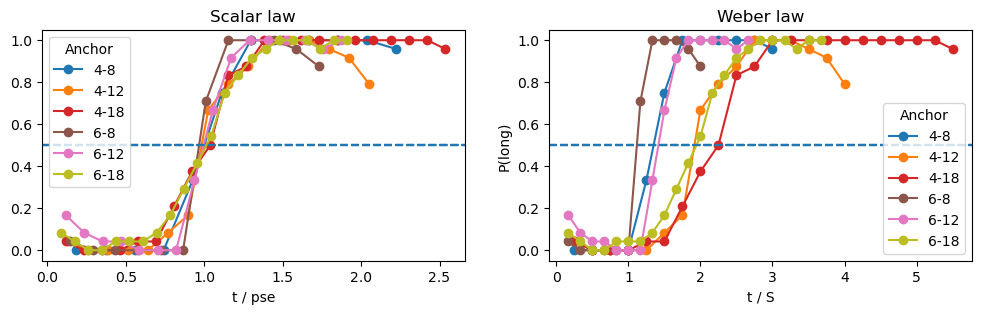

In [117]:
# superimposition plots 
fig2, ax2 = plt.subplots(1, 2, figsize=(12,3))

for j, x_norm in enumerate(["bp","short"]):
    for i, (anchor, anchor_data) in enumerate(delivery_counter_used_history.items()):
        # print(anchor)
        short = int(anchor.split("-")[0])
        long = int(anchor.split("-")[-1]) 
        cmap = plt.cm.tab10
        color = cmap(i / 6)
    
        # get mean plong 
        participant_plong = get_participant_plong(anchor_data, anchor)
        groupmean_superimposition_plot(participant_plong, anchor, x_norm=x_norm, ax=ax2[j], color=color)
# plt.xlabel("Probe duration")
plt.ylabel("P(long)")

In [ ]:
#LSTM 8

4-8
4-12
4-18
6-8
6-12
6-18


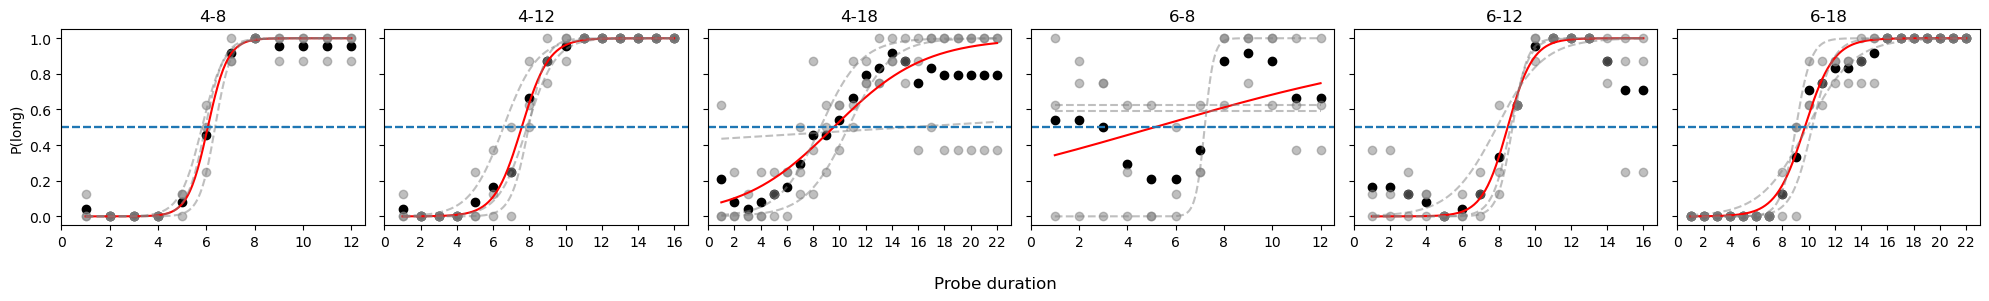

In [62]:
# psychometric_curve(delivery_counter_used_history['4-8'])
fig, ax = plt.subplots(1, 6, sharey=True, figsize=(20,3))
mean_wf = []
# avg_pse_dl_wf_df = pd.DataFrame()
rows = []
for i, (anchor, anchor_data) in enumerate(delivery_counter_used_history_256.items()):
    print(anchor)
    short = int(anchor.split("-")[0])
    long = int(anchor.split("-")[-1])    
    bp_ts, dl_ts, wf_ts = [], [], []

    # get mean plong 
    participant_plong = get_participant_plong(anchor_data, anchor)
    x0_mean, k_mean = groupmean_psychometric_curve(participant_plong, label=anchor, ax=ax[i])
    
    #plot psychometric curve per participant and group mean 
    for ts, data in anchor_data.items():
        x0, k = psychometric_curve(data, label=anchor, ax=ax[i])
        if (x0 == 0) and (k==0):
            bp = round(((np.min([k for k, v in participant_plong[ts].items() if v>=0.5]) + np.max([k for k, v in participant_plong[ts].items() if v<=0.5]))/2),3) # first check why curve cannot fit. Mostly a step function. manual calculate of bp, dl ,wf 
            dl25 = (np.min([k for k, v in participant_plong[ts].items() if v>=0.25]) + np.max([k for k, v in participant_plong[ts].items() if v<=0.25]))/2
            dl75 = (np.min([k for k, v in participant_plong[ts].items() if v>=0.75]) + np.max([k for k, v in participant_plong[ts].items() if v<=0.75]))/2
            dl = round(0.5*(dl75-dl25),3)
        else:
            bp = round(inv_logistic(0.5, x0, k),3)
            dl = round(0.5*(inv_logistic(0.75, x0, k)-inv_logistic(0.25, x0, k)),3)

        wf = round(dl/bp,3)
                
        rows.append({"anchor":anchor, "p_id":ts, "x0":x0, "k":k, "pse":bp, "dl":dl, "AM":(short+long)/2, "GM":round(np.sqrt(long*short),3), "wf":wf, 
                     "L/S":np.round(long/short,2), "L-S":long-short})

avg_pse_dl_wf_df = pd.DataFrame(rows)    
avg_pse_dl_wf_df["pse/AM"] = avg_pse_dl_wf_df["pse"]/avg_pse_dl_wf_df["AM"]
avg_pse_dl_wf_df["pse/GM"] = avg_pse_dl_wf_df["pse"]/avg_pse_dl_wf_df["GM"]
avg_pse_dl_wf_df["closer_AM_GM"] = avg_pse_dl_wf_df.apply(lambda x: "AM" if np.abs(x["pse/AM"] - 1) < np.abs(x["pse/GM"] - 1) else "GM", axis=1 )
ax[0].set_ylabel("P(long)")
fig.supxlabel("Probe duration")

plt.tight_layout()
plt.show()

In [64]:
delivery_counter_used_history_256

{'4-8': {'2-950000': {1: [1, 1, 1, 1, 1, 1, 1, 1],
   2: [1, 1, 1, 1, 1, 1, 1, 1],
   3: [1, 1, 1, -1, 1, 1, 1, 1],
   4: [1, 1, 1, 1, 1, 1, 1, 1],
   5: [1, 2, 1, -1, 1, 1, 1, 1],
   6: [1, 2, 2, 2, 2, 1, 1, 1],
   7: [2, 2, 2, 2, 2, 2, 2, 2],
   8: [2, 2, 2, 2, 2, 2, 2, 2],
   9: [2, 2, 2, 1, 2, 2, 2, 2],
   10: [2, 2, 2, 1, 2, 2, 2, 2],
   11: [2, 2, 2, 1, 2, 2, 2, 2],
   12: [2, 2, 2, 1, 2, 2, 2, 2]},
  '3-950000': {1: [1, 1, 1, -1, 1, 1, 1, 1],
   2: [1, 1, 1, 1, 1, 1, 1, 1],
   3: [1, 1, 1, 1, 1, 1, 1, 1],
   4: [1, 1, 1, 1, 1, 1, 1, 1],
   5: [1, 1, 1, 2, 1, 1, 1, 1],
   6: [1, 2, 2, 2, 1, 1, 2, 2],
   7: [2, 2, 2, 2, 2, 1, 2, 2],
   8: [2, 2, 2, 2, 2, 2, 2, 2],
   9: [2, 2, 2, 2, 2, 2, 2, 2],
   10: [2, 2, 2, 2, 2, 2, 2, 2],
   11: [2, 2, 2, 2, 2, 2, 2, 2],
   12: [2, 2, 2, 2, 2, 2, 2, 2]},
  '4-950000': {1: [2, 1, 1, 1, 1, 1, 1, 1],
   2: [1, 1, 1, 1, 1, 1, 1, 1],
   3: [1, 1, 1, 1, 1, 1, 1, 1],
   4: [1, 1, 1, 1, 1, 1, 1, 1],
   5: [1, 1, 1, 1, 1, 1, 1, 1],
   6: [2, 1, 1, 1,

In [63]:
# % percentage of AM and GM
avg_pse_dl_wf_df["closer_AM_GM"].value_counts(normalize=True) * 100

closer_AM_GM
AM    55.555556
GM    44.444444
Name: proportion, dtype: float64

In [133]:
# pse avg 
pse_df = avg_pse_dl_wf_df[["anchor","L/S","L-S","pse","AM","GM"]].groupby(["anchor","L/S","L-S"]).agg(
    pse_mean=("pse", "mean"),
    pse_std=("pse", "std"),
        GM=("GM", "mean"),
    AM=("AM", "mean")

).sort_values(by="L/S")

pse_df["mean_pse/gm"] = pse_df["pse_mean"]/pse_df["GM"]
pse_df["mean_pse/am"] = pse_df["pse_mean"]/pse_df["AM"]
pse_df

,,,pse_mean,pse_std,GM,AM,mean_pse/gm,mean_pse/am
anchor,L/S,L-S,,,,,,
6-8,1.33,2,3.9405,4.451237,6.928,7.0,0.568779,0.562929
6-12,2.00,6,9.3130,0.442649,8.485,9.0,1.097584,1.034778
4-8,2.00,4,6.1360,0.067882,5.657,6.0,1.084674,1.022667
4-12,3.00,8,8.1550,0.159806,6.928,8.0,1.177107,1.019375
6-18,3.00,12,9.9735,1.294713,10.392,12.0,0.959729,0.831125
4-18,4.50,14,9.7045,0.601748,8.485,11.0,1.143724,0.882227


In [129]:
# dl avg 
pse_df = avg_pse_dl_wf_df[["anchor","L/S","L-S","dl","AM","GM"]].groupby(["anchor","L/S","L-S"]).agg(
    dl_mean=("dl", "mean"),
    dl_std=("dl", "std"),
).sort_values(by="L-S")

pse_df

,,,dl_mean,dl_std
anchor,L/S,L-S,,
4-12,3.00,8,0.5560,0.197990
4-8,2.00,4,0.5840,0.107480
6-12,2.00,6,0.5890,0.299813
4-18,4.50,14,0.7445,0.572049
6-18,3.00,12,0.8635,0.077075
6-8,1.33,2,1.6205,1.358352


In [130]:
# WF
# dl avg 
wf_df = avg_pse_dl_wf_df[["anchor","L/S","L-S","wf","AM","GM"]].groupby(["anchor","L/S","L-S"]).agg(
    wf_mean=("wf", "mean"),
    wf_std=("wf", "std"),
).sort_values(by="L/S")

wf_df

,,,wf_mean,wf_std
anchor,L/S,L-S,,
6-8,1.33,2,1.6740,2.235872
6-12,2.00,6,0.0640,0.035355
4-8,2.00,4,0.0950,0.018385
4-12,3.00,8,0.0680,0.022627
6-18,3.00,12,0.0865,0.003536
4-18,4.50,14,0.0790,0.063640


Text(0, 0.5, 'P(long)')

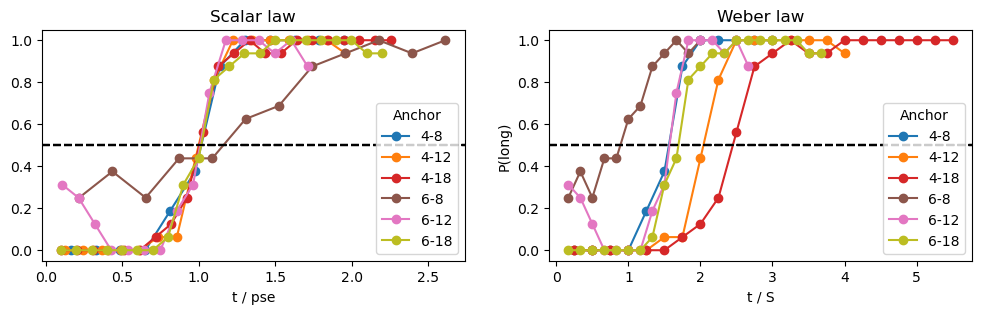

In [153]:
# superimposition plots 
fig2, ax2 = plt.subplots(1, 2, figsize=(12,3))

for j, x_norm in enumerate(["bp","short"]):
    for i, (anchor, anchor_data) in enumerate(delivery_counter_used_history_256.items()):
        # print(anchor)
        short = int(anchor.split("-")[0])
        long = int(anchor.split("-")[-1]) 
        cmap = plt.cm.tab10
        color = cmap(i / 6)
    
        # get mean plong 
        participant_plong = get_participant_plong(anchor_data, anchor)
        groupmean_superimposition_plot(participant_plong, anchor, x_norm=x_norm, ax=ax2[j], color=color)
# plt.xlabel("Probe duration")
plt.ylabel("P(long)")

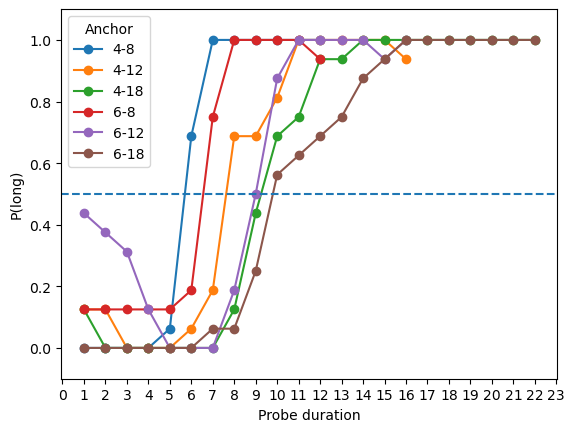

In [22]:
# plot all curves in one graph
# for anchor, data in delivery_counter_used_history.items():
#     durations = sorted(data.keys())
#     prop_long = [np.mean(np.array(data[d]) == 2) for d in durations]

#     plt.plot(durations, prop_long, marker='o', label=f"{anchor}")

# plt.xlabel("Probe duration")
# plt.ylabel("P(long)")
# plt.ylim(-0.1, 1.1)
# plt.xticks(range(24))
# plt.axhline(0.5, linestyle='--')
# plt.legend(title="Anchor")
# # plt.grid(True)
# plt.show()

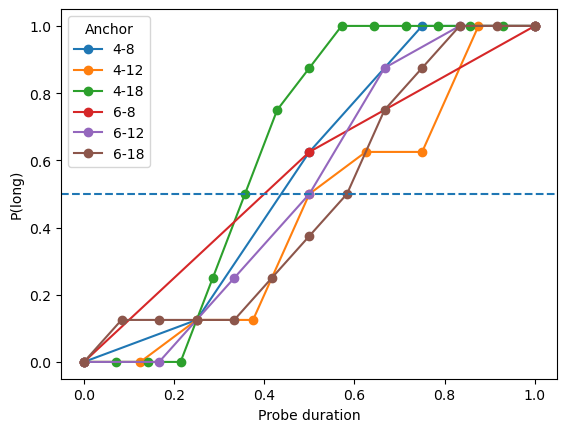

In [45]:
# superimposiiton 
# plot all curves in one graph
for anchor, data in delivery_counter_used_history.items():
    short = int(anchor.split("-")[0])
    long = int(anchor.split("-")[-1])
    d2 = {k:v for k, v in data.items() if (k>=short) and (k<=long)}
    durations = sorted(d2.keys())

    prop_long = [np.mean(np.array(d2[d]) == 2) for d in durations]


    x_norm = [(x - short) / (long - short) for x in durations]    

    plt.plot(x_norm, prop_long, marker='o', label=f"{anchor}")
    # break

plt.xlabel("Probe duration")
plt.ylabel("P(long)")
# plt.ylim(-0.1, 1.1)
# plt.xticks(range(24))
plt.axhline(0.5, linestyle='--')
plt.legend(title="Anchor")
# plt.grid(True)
plt.show()

4-8 1.4470547001466803 0.09380766546853012 1.447
4-12 2.126382630653797 0.2834979704400973 2.126
4-18 2.2637949108532354 0.203680705830431 2.264
could not fit a sigmoid
6-8 0 0 0.0
6-12 1.482426275066474 0.10385701786754022 1.482
6-18 2.0981697210802897 0.23174255993949955 2.098


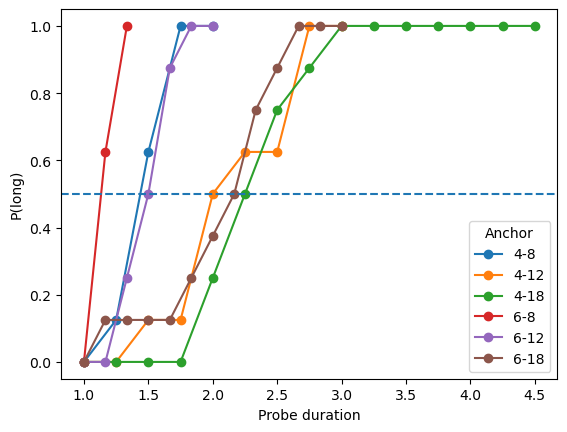

In [17]:
# superimposiiton - T/pse and T/s
# plot all curves in one graph
for anchor, ts_data in delivery_counter_used_history.items():
    short = int(anchor.split("-")[0])
    long = int(anchor.split("-")[-1])
    # if long != 18:
    #     continue
    for ts, data in ts_data.items(): 
        
        # data = {k:v for k, v in data.items() if (k>=short) and (k<=long)}
        data2 = {k/short:v for k, v in data.items() if (k>=short) and (k<=long)}
        # durations = sorted(data.keys())
        durations = sorted(data2.keys())
    
        # prop_long = [np.mean(np.array(data[d]) == 2) for d in durations]
        prop_long = [np.mean(np.array(data2[d]) == 2) for d in durations]
        
        x0, k = psychometric_curve(data2, ax=ax[i], label=anchor)
        bp = round(inv_logistic(0.5, x0, k),3)
        print(anchor, x0,k,bp)
    
        # x_norm = [x / bp  for x in durations]  
        # x_norm = [x / short  for x in durations] 
        x_norm = [x   for x in durations] 
    
        plt.plot(x_norm, prop_long, marker='o', label=f"{anchor}")
        break


plt.xlabel("Probe duration")
plt.ylabel("P(long)")
# plt.ylim(-0.1, 1.1)
# plt.xticks(range(24))
plt.axhline(0.5, linestyle='--')
plt.legend(title="Anchor")
# plt.grid(True)
plt.show()